# Corrected Jin++ ENSO: interactive full reproduction

## Goal

This notebook is the scientific workbench for the paper. It constructs every
simulation and diagnostic from the included 1979--2025 observational CSV,
builds each of the eleven paper figures from live Python objects, and can
export the same vector PDF/SVG files used by the manuscript.

Nothing below reads precomputed model trajectories or figure files. The
notebook draws on the documented functions in `src/`, but exposes the model
parameters, experiment loops, diagnostics, plotting calls, and export choices
in editable cells. The delayed pathway is a **wind-forced memory proxy**, not
a resolved wind-stress-curl or spatial Rossby-wave model.

## How to work with it

1. Run top-to-bottom with `MODE = "full"` to reproduce the paper.
2. Use `MODE = "quick"` while editing plotting code or checking machinery.
3. Change values in `PARAMETER_OVERRIDES`, `CONFIG_OVERRIDES`, or the widget
   explorer and rerun only the affected cells.
4. Every figure cell starts with an **EDIT CONTROLS** block containing its
   colours, title, size, selections, limits, and sensitivity choices. The
   complete Matplotlib implementation and export call are in that same cell.
5. Set `EXPORT_STATIC = False` when exploring so reruns do not overwrite the
   paper figures. There is no hidden notebook plotting wrapper.

Full-mode statistics are exploratory, in-sample simulator diagnostics. The
score is an engineering summary, not a likelihood or forecast score.

## 1. Setup and public building blocks

In [2]:
from dataclasses import asdict, replace
from pathlib import Path
import hashlib
import json
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib"))

# Set True for a pan/zoom-enabled ipympl canvas. Leave False for the most
# portable inline rendering and for static nbconvert execution.
INTERACTIVE_CANVAS = False
if INTERACTIVE_CANVAS:
    from IPython import get_ipython
    get_ipython().run_line_magic("matplotlib", "widget")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
try:
    from IPython.display import display
except ImportError:  # Allows a plain-Python validation pass before Jupyter install.
    def display(value):
        print(value)

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
if not (ROOT / "src").exists():
    raise FileNotFoundError("Start Jupyter in the bundle root or notebooks/ directory.")
sys.path.insert(0, str(ROOT))

from src.baselines import generate_baselines
from src.metrics import (
    ALL_METRICS,
    CORE_METRICS,
    evaluate_models,
    lead_lag_correlation,
    scale_model_output,
    separated_peaks,
    spectrum_period,
)
from src.model import default_parameters, simulate_jinpp, with_updates
from src.pipeline import (
    ReproductionConfig,
    apply_ablation,
    load_observations,
    perturb_parameter_group,
)
print(f"Project root: {ROOT}")

Project root: /gws/ssde/j25a/ncas_climate/vol1/users/kieran/enso-oscillator/v2


### Editable run, model, and export configuration

In [3]:
# "full" reproduces the manuscript; "quick" is for rapid tinkering.
MODE = "full"

# Any ReproductionConfig field may be changed here, for example:
# CONFIG_OVERRIDES = {"reference_years": 400.0, "dt": 1/48}
CONFIG_OVERRIDES = {}

# Change any entry returned by default_parameters(). Examples:
# PARAMETER_OVERRIDES = {"memory_factor": 1.4, "quadE": 0.9}
PARAMETER_OVERRIDES = {}

EXPORT_STATIC = True
EXPORT_TABLES = True
FIGURE_FORMATS = ("pdf", "svg")       # add "png" if wanted
FIGURE_DPI = 180

config = replace(ReproductionConfig.for_mode(MODE), **CONFIG_OVERRIDES)
parameters = with_updates(default_parameters(), **PARAMETER_OVERRIDES)

FIGURE_DIR = ROOT / "output" / "figures"
TABLE_DIR = ROOT / "output" / "data"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

pd.Series(asdict(config), name="value").to_frame()

,value
mode,full
reference_years,1650.0
reference_burn,100.0
ablation_years,900.0
ablation_burn,100.0
sensitivity_years,700.0
sensitivity_burn,100.0
perturbation_years,12.0
dt,0.020833
reference_seed,20260614


### Model state and numerical interpretation

`simulate_jinpp` advances the fourteen states
$T_E,T_C,H,H_N,H_S,U,K,q,e,m,R_1,R_2,R_3,R_K$. Nonlinear stochastic
tendencies for $T_E,T_C,H$ use a simultaneous old-state Euler--Maruyama step.
Linear filters use exponential updates. Wind bursts are compound-Poisson
events with within-step event times and exact exponential decay.

The complete parameter dictionary is deliberately visible. Filter it by text
or edit selected values through `PARAMETER_OVERRIDES` above.

In [4]:
parameter_table = (
    pd.Series(parameters, name="value")
    .rename_axis("parameter")
    .reset_index()
)
parameter_table

,parameter,value
0,RC0,-0.734556
1,RC_m,0.150000
2,RC_season,1.400000
3,RE0,-0.882364
4,RE_m,0.250000
...,...,...
110,tau_m,8.000000
111,tau_q,0.080000
112,tau_sst,0.238653
113,windC,0.121129


## 2. Load and inspect the sole scientific input

In [5]:
observations = load_observations(
    ROOT / "data" / "enso_observation_indices_1979_2025.csv"
)
display(observations.head())
print(f"{len(observations)} uninterrupted months: "
      f"{observations.date.iloc[0]:%Y-%m} to {observations.date.iloc[-1]:%Y-%m}")

,date,nino34_sst,nino3_sst,heat,nino34,nino3,east_gradient,month,year
0,1979-01-01,26.41,25.34,0.49,-0.142333,-0.326667,-0.184333,1,1979
1,1979-02-01,26.53,26.12,0.85,-0.211667,-0.288333,-0.076667,2,1979
2,1979-03-01,27.27,27.15,0.36,0.035333,-0.008000,-0.043333,3,1979
3,1979-04-01,27.83,27.65,-0.09,0.120333,0.169000,0.048667,4,1979
4,1979-05-01,27.69,27.20,0.12,-0.122000,0.042000,0.164000,5,1979


564 uninterrupted months: 1979-01 to 2025-12


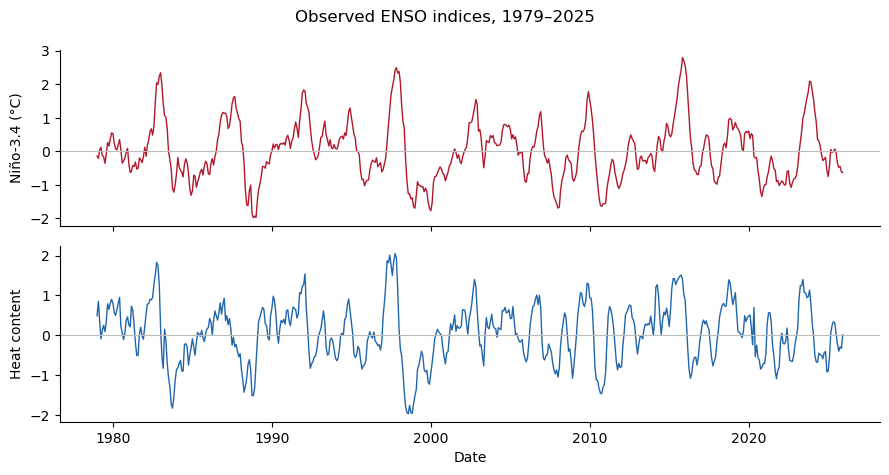

In [6]:
# --- EDIT CONTROLS ---------------------------------------------------------
OBS_TITLE = "Observed ENSO indices, 1979–2025"
OBS_FIGURE_SIZE = (9.0, 4.8)
OBS_COLOURS = {"nino34": "#b2182b", "heat": "#2166ac", "zero": "#bdbdbd"}
OBS_LINE_WIDTH = 1.0
OBS_FONT_SIZE = 10.0
# --------------------------------------------------------------------------

plt.rcParams.update({
    "font.size": OBS_FONT_SIZE,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
fig, axes = plt.subplots(2, 1, figsize=OBS_FIGURE_SIZE, sharex=True)
axes[0].plot(
    observations["date"], observations["nino34"],
    color=OBS_COLOURS["nino34"], lw=OBS_LINE_WIDTH,
)
axes[0].axhline(0, color=OBS_COLOURS["zero"], lw=0.8)
axes[0].set_ylabel("Niño-3.4 (°C)")
axes[1].plot(
    observations["date"], observations["heat"],
    color=OBS_COLOURS["heat"], lw=OBS_LINE_WIDTH,
)
axes[1].axhline(0, color=OBS_COLOURS["zero"], lw=0.8)
axes[1].set_ylabel("Heat content")
axes[1].set_xlabel("Date")
fig.suptitle(OBS_TITLE)
fig.tight_layout()

## 3. Construct the reference model hierarchy from scratch

The two Jin++ simulations use the same parameter dictionary, time step, seed,
and initial state. Only `memory_factor` differs. The remaining baselines are
then fitted directly to the observational columns and simulated for the same
number of months.

In [7]:
memory_off_raw = simulate_jinpp(
    with_updates(parameters, memory_factor=0.0),
    years=config.reference_years,
    burn=config.reference_burn,
    dt=config.dt,
    seed=config.reference_seed,
)
memory_on_raw = simulate_jinpp(
    with_updates(parameters, memory_factor=1.0),
    years=config.reference_years,
    burn=config.reference_burn,
    dt=config.dt,
    seed=config.reference_seed,
)

# This affine observation-unit mapping is explicit and shared by all
# conceptual models; raw columns remain available in memory_*_raw.
memory_off = scale_model_output(memory_off_raw, observations)
memory_on = scale_model_output(memory_on_raw, observations)

analysis_months = len(memory_on)
baselines = generate_baselines(
    observations,
    months=analysis_months,
    seed=config.reference_seed + 100,
)
baselines["Linear Jin RO"] = scale_model_output(
    baselines["Linear Jin RO"], observations
)
models = {
    **baselines,
    "Jin++ (memory off)": memory_off,
    "Jin++ (memory on)": memory_on,
}

pd.DataFrame(
    {"model": list(models), "months": [len(frame) for frame in models.values()]}
)

,model,months
0,AR(1),18600
1,Seasonal AR(1),18600
2,Seasonal AR(2),18600
3,Seasonal recharge VAR,18600
4,Linear Jin RO,18600
5,Jin++ (memory off),18600
6,Jin++ (memory on),18600


### Inspect raw state variables before scoring

In [8]:
state_columns = [
    "nino34_raw", "heat_raw", "recharge_raw", "tau", "q", "e", "m",
    "offequatorial_mean", "memory_1", "memory_2", "memory_return",
    "kelvin_return", "burst_q_count", "burst_e_count",
]
memory_on_raw[state_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
nino34_raw,18600.0,-0.388350,0.301920,-1.237424e+00,-5.880422e-01,-3.989586e-01,-2.076258e-01,0.973607
heat_raw,18600.0,-0.887243,0.784837,-4.252512e+00,-1.295372e+00,-8.845461e-01,-5.203208e-01,3.494359
recharge_raw,18600.0,-0.385465,0.534211,-3.834061e+00,-6.131526e-01,-2.614818e-01,-7.337854e-03,0.424979
tau,18600.0,-0.082123,0.433737,-9.512140e-01,-2.944702e-01,-1.993220e-01,-7.717501e-02,3.932784
q,18600.0,0.132965,0.371823,7.038379e-27,1.046597e-08,1.136516e-04,2.594467e-02,3.690251
e,18600.0,0.003979,0.028223,1.061460e-149,9.038930e-33,8.690838e-18,1.768099e-08,0.779492
m,18600.0,0.018748,0.160683,-5.259562e-01,-9.424367e-02,1.817030e-02,1.316047e-01,0.544328
offequatorial_mean,18600.0,-0.640536,0.140515,-1.326251e+00,-7.243529e-01,-6.219483e-01,-5.404545e-01,-0.239932
memory_1,18600.0,-0.115472,0.312366,-3.952865e+00,-1.182411e-01,6.825501e-03,2.814399e-02,0.081005
memory_2,18600.0,-0.115360,0.189629,-1.757438e+00,-1.586173e-01,-5.072636e-02,6.113427e-03,0.054532


## 4. Interactive parameter explorer

This short-run explorer is independent of the manuscript-length objects above.
It is safe for experimenting with memory strength, eastern-Pacific asymmetry,
thermocline coupling, seasonality, and random seed. Press **Run interact** after
changing a slider. For experiments involving other parameters, copy the
`run_custom_model` call and pass any valid parameter name in `updates`.

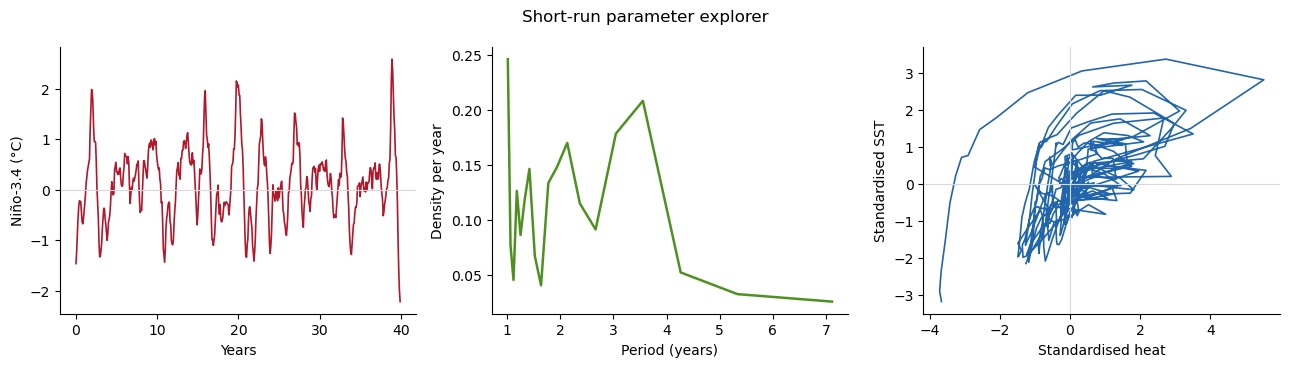

In [9]:
# --- EDIT CONTROLS ---------------------------------------------------------
CUSTOM_TITLE = "Short-run parameter explorer"
CUSTOM_FIGURE_SIZE = (13.0, 3.7)
CUSTOM_YEARS_TO_SHOW = 40
CUSTOM_PERIOD_LIMITS = (1.0, 10.0)
CUSTOM_COLOURS = {
    "nino34": "#b2182b", "spectrum": "#4d9221",
    "phase": "#2166ac", "zero": "#d9d9d9",
}
CUSTOM_LINE_WIDTH = 1.2
# --------------------------------------------------------------------------

def run_custom_model(
    *,
    years=100.0,
    burn=20.0,
    seed=20260720,
    updates=None,
):
    custom_parameters = with_updates(parameters, **(updates or {}))
    raw = simulate_jinpp(
        custom_parameters,
        years=years,
        burn=burn,
        dt=config.dt,
        seed=seed,
    )
    return raw, scale_model_output(raw, observations)


def custom_dashboard(frame, *, years_to_show=CUSTOM_YEARS_TO_SHOW):
    x = frame["nino34"].to_numpy(float)
    h = frame["heat"].to_numpy(float)
    n = min(len(x), int(years_to_show * 12))
    period, density = spectrum_period(x)
    use = (period >= CUSTOM_PERIOD_LIMITS[0]) & (period <= CUSTOM_PERIOD_LIMITS[1])
    fig, axes = plt.subplots(1, 3, figsize=CUSTOM_FIGURE_SIZE)
    axes[0].plot(
        np.arange(n) / 12, x[:n],
        color=CUSTOM_COLOURS["nino34"], lw=CUSTOM_LINE_WIDTH,
    )
    axes[0].axhline(0, color=CUSTOM_COLOURS["zero"], lw=0.8)
    axes[0].set(xlabel="Years", ylabel="Niño-3.4 (°C)")
    axes[1].plot(
        period[use], density[use],
        color=CUSTOM_COLOURS["spectrum"], lw=CUSTOM_LINE_WIDTH + 0.6,
    )
    axes[1].set(xlabel="Period (years)", ylabel="Density per year")
    axes[2].plot((h[:n]-h[:n].mean())/h[:n].std(),
                 (x[:n]-x[:n].mean())/x[:n].std(),
                 color=CUSTOM_COLOURS["phase"], lw=CUSTOM_LINE_WIDTH)
    axes[2].axhline(0, color=CUSTOM_COLOURS["zero"], lw=0.8)
    axes[2].axvline(0, color=CUSTOM_COLOURS["zero"], lw=0.8)
    axes[2].set(xlabel="Standardised heat", ylabel="Standardised SST")
    fig.suptitle(CUSTOM_TITLE)
    fig.tight_layout()
    return fig

# Non-widget example: edit the dictionary and rerun.
custom_raw, custom_model = run_custom_model(
    updates={"memory_factor": 1.0}, years=80.0, burn=20.0
)
fig_custom = custom_dashboard(custom_model)

In [10]:
try:
    import ipywidgets as widgets

    @widgets.interact_manual(
        memory_factor=widgets.FloatSlider(value=1.0, min=0.0, max=2.0, step=0.1),
        quadE_scale=widgets.FloatSlider(value=1.0, min=0.0, max=2.0, step=0.1),
        alphaE_scale=widgets.FloatSlider(value=1.0, min=0.5, max=1.5, step=0.05),
        seasonal_scale=widgets.FloatSlider(value=1.0, min=0.0, max=1.5, step=0.1),
        seed=widgets.IntText(value=config.experiment_seed),
    )
    def interactive_explorer(
        memory_factor, quadE_scale, alphaE_scale, seasonal_scale, seed
    ):
        _, frame = run_custom_model(
            years=80.0,
            burn=20.0,
            seed=seed,
            updates={
                "memory_factor": memory_factor,
                "quadE": parameters["quadE"] * quadE_scale,
                "alphaE": parameters["alphaE"] * alphaE_scale,
                "RE_season": parameters["RE_season"] * seasonal_scale,
                "RC_season": parameters["RC_season"] * seasonal_scale,
            },
        )
        display(custom_dashboard(frame))
        plt.close("all")
except ImportError:
    print("Install ipywidgets to enable sliders; run_custom_model remains available.")

interactive(children=(FloatSlider(value=1.0, description='memory_factor', max=2.0), FloatSlider(value=1.0, des…

## 5. Compute the shared diagnostic scorecard

Warm and cold peaks are found after centred three-month smoothing. Spectral
comparisons are calculated in frequency, while period plots use
$S_P(P)=S_f(1/P)/P^2$. `core_rms_score` is the RMS of the 14 normalised errors
available to every model; `recharge_rms_score` adds the heat-lead metric.
The Period metric locates the peak of a 256-month Welch spectrum on a
2,048-point zero-padded FFT grid. This reduces coarse-bin ties but does not
add independent frequency resolution.

In [11]:
statistics, errors, scores = evaluate_models(observations, models)
scores.sort_values("core_rms_score").reset_index(drop=True)

,model,core_rms_score,recharge_rms_score
0,Observed,0.000000,0.000000
1,Jin++ (memory on),0.522027,0.527649
2,Jin++ (memory off),0.557325,0.540831
3,Seasonal recharge VAR,0.964722,0.939289
4,Seasonal AR(2),1.358037,NaN
5,Linear Jin RO,2.279547,2.202618
6,Seasonal AR(1),2.280048,NaN
7,AR(1),3.108797,NaN


In [12]:
statistics.set_index("model").loc[
    ["Observed", "Linear Jin RO", "Jin++ (memory off)", "Jin++ (memory on)"],
    ["skew", "kurt", "ac12", "period", "winter_peak", "phase_lock",
     "L_to_L", "H_leads_T_6m"],
]

,skew,kurt,ac12,period,winter_peak,phase_lock,L_to_L,H_leads_T_6m
model,,,,,,,,
Observed,0.500999,0.298160,-0.068035,5.019608,0.833333,0.787495,0.470588,0.602805
Linear Jin RO,-0.030219,0.133652,-0.257699,3.413333,0.287565,0.029341,0.188095,0.626165
Jin++ (memory off),0.343571,0.382563,-0.081965,3.968992,0.774436,0.785332,0.386850,0.632395
Jin++ (memory on),0.383919,0.474281,-0.022902,4.491228,0.726542,0.739740,0.436047,0.692932


## 6. Run the mechanism-denial experiments

In [13]:
# --- EDIT EXPERIMENT CONTROLS ---------------------------------------------
ABLATION_NAMES = [
    "Full model",
    "No delayed memory",
    "No seasonality",
    "No wind bursts",
    "No SST quadratic asymmetry",
    "No zonal-current SST coupling",
    "Constant-amplitude SST noise",
    "No slow mean state",
]
ABLATION_YEARS = config.reference_years
ABLATION_BURN = config.reference_burn
ABLATION_DT = config.dt
ABLATION_SEED = config.reference_seed
# --------------------------------------------------------------------------

ablation_models = {}
ablation_parameters = with_updates(parameters, memory_factor=1.0)
for name in ABLATION_NAMES:
    raw = simulate_jinpp(
        apply_ablation(ablation_parameters, name),
        years=ABLATION_YEARS,
        burn=ABLATION_BURN,
        dt=ABLATION_DT,
        seed=ABLATION_SEED,
    )
    ablation_models[name] = scale_model_output(raw, observations)

ablation_statistics_all, ablation_errors_all, ablation_scores_all = evaluate_models(
    observations, ablation_models
)
ablation_statistics = ablation_statistics_all.query("model != 'Observed'").reset_index(drop=True)
ablation_errors = ablation_errors_all.query("model != 'Observed'").reset_index(drop=True)
ablation_scores = ablation_scores_all.query("model != 'Observed'").reset_index(drop=True)
ablation_scores.sort_values("core_rms_score")

,model,core_rms_score,recharge_rms_score
6,Constant-amplitude SST noise,0.519959,0.525712
0,Full model,0.522027,0.527649
5,No zonal-current SST coupling,0.536295,0.536499
1,No delayed memory,0.557325,0.540831
7,No slow mean state,0.564121,0.565426
4,No SST quadratic asymmetry,0.665094,0.666779
3,No wind bursts,1.340362,1.324713
2,No seasonality,1.984871,1.933457


## 7. Run delayed-memory strength sensitivity

In [14]:
# --- EDIT EXPERIMENT CONTROLS ---------------------------------------------
MEMORY_FACTORS = np.linspace(0.0, 1.8, 10)
SENSITIVITY_YEARS = config.sensitivity_years
SENSITIVITY_BURN = config.sensitivity_burn
SENSITIVITY_DT = config.dt
SENSITIVITY_SEED = config.experiment_seed + 1
# --------------------------------------------------------------------------

sensitivity_models = {}
sensitivity_names = []
for factor in MEMORY_FACTORS:
    name = f"Memory factor {factor:.1f}"
    sensitivity_names.append(name)
    raw = simulate_jinpp(
        with_updates(parameters, memory_factor=float(factor)),
        years=SENSITIVITY_YEARS,
        burn=SENSITIVITY_BURN,
        dt=SENSITIVITY_DT,
        seed=SENSITIVITY_SEED,
    )
    sensitivity_models[name] = scale_model_output(raw, observations)

sens_stats_all, _, sens_scores_all = evaluate_models(observations, sensitivity_models)
sens_stats = sens_stats_all.set_index("model").loc[sensitivity_names]
sens_scores = sens_scores_all.set_index("model").loc[sensitivity_names]
observed_stats = statistics.set_index("model").loc["Observed"]
sensitivity = pd.DataFrame({
    "model": sensitivity_names,
    "memory_factor": MEMORY_FACTORS,
    "core_rms_score": sens_scores["core_rms_score"].to_numpy(float),
    "recharge_rms_score": sens_scores["recharge_rms_score"].to_numpy(float),
    "L_to_L": sens_stats["L_to_L"].to_numpy(float),
    "L_to_L_error": np.abs(sens_stats["L_to_L"].to_numpy(float) - observed_stats["L_to_L"]),
    "ac12": sens_stats["ac12"].to_numpy(float),
    "ac12_error": np.abs(sens_stats["ac12"].to_numpy(float) - observed_stats["ac12"]),
    "spectrum_error": sens_stats["spectrum_error"].to_numpy(float),
    "period": sens_stats["period"].to_numpy(float),
})
sensitivity

,model,memory_factor,core_rms_score,recharge_rms_score,L_to_L,L_to_L_error,ac12,ac12_error,spectrum_error,period
0,Memory factor 0.0,0.0,0.599086,0.582678,0.423664,0.046924,-0.043341,0.024694,0.670161,4.266667
1,Memory factor 0.2,0.2,0.592071,0.576659,0.427509,0.043079,-0.080318,0.012282,0.632805,3.878788
2,Memory factor 0.4,0.4,0.516819,0.510903,0.413534,0.057054,-0.058306,0.009729,0.560990,4.266667
3,Memory factor 0.6,0.6,0.483709,0.480151,0.400778,0.069810,-0.061551,0.006485,0.534470,4.612613
4,Memory factor 0.8,0.8,0.563052,0.555983,0.428044,0.042544,-0.050636,0.017400,0.628387,3.878788
5,Memory factor 1.0,1.0,0.488941,0.494181,0.425373,0.045215,-0.056531,0.011504,0.592968,4.162602
6,Memory factor 1.2,1.2,0.579516,0.582068,0.421260,0.049328,-0.011722,0.056313,0.640725,4.612613
7,Memory factor 1.4,1.4,0.539308,0.546507,0.432950,0.037638,0.001311,0.069347,0.637658,4.740741
8,Memory factor 1.6,1.6,0.604772,0.605659,0.468635,0.001954,-0.002215,0.065820,0.629781,4.376068
9,Memory factor 1.8,1.8,0.599586,0.614859,0.452107,0.018481,0.028987,0.097022,0.697817,4.491228


## 8. Run common-seed parameter perturbations

In [15]:
# --- EDIT EXPERIMENT CONTROLS ---------------------------------------------
PERTURBATION_GROUPS = [
    "Thermocline feedback", "Seasonal growth", "Wind-burst rate", "Delayed memory"
]
PERTURBATION_FACTORS = (0.7, 1.0, 1.3)
PERTURBATION_YEARS = 15.0
PERTURBATION_BURN = 0.0
PERTURBATION_DT = config.dt
PERTURBATION_SEED = config.experiment_seed + 2
# --------------------------------------------------------------------------

perturbation_rows = []
for experiment in PERTURBATION_GROUPS:
    for factor in PERTURBATION_FACTORS:
        raw = simulate_jinpp(
            perturb_parameter_group(parameters, experiment, factor),
            years=PERTURBATION_YEARS,
            burn=PERTURBATION_BURN,
            dt=PERTURBATION_DT,
            seed=PERTURBATION_SEED,
        )
        scaled = scale_model_output(raw, observations)
        for month_index, value in enumerate(scaled["nino34"].to_numpy(float)):
            perturbation_rows.append({
                "experiment": experiment,
                "factor": factor,
                "month_index": month_index,
                "year": month_index / 12.0,
                "nino34": value,
            })
perturbations = pd.DataFrame(perturbation_rows)
perturbations.head()

,experiment,factor,month_index,year,nino34
0,Thermocline feedback,0.7,0,0.000000,0.888294
1,Thermocline feedback,0.7,1,0.083333,1.013952
2,Thermocline feedback,0.7,2,0.166667,0.729174
3,Thermocline feedback,0.7,3,0.250000,0.882941
4,Thermocline feedback,0.7,4,0.333333,0.827813


## 9. Build every paper figure from live objects

Each cell below is deliberately self-contained. Edit the clearly marked
controls at its top to change titles, colours, labels, model selections,
limits, or sensitivity definitions; the full Matplotlib construction and
optional export are visible immediately below. Rerun only that cell to update
one figure. Set `EXPORT_STATIC = False` above while experimenting.

In [16]:
created_figures = {}

### Figure 1 — modelling hierarchy and scope

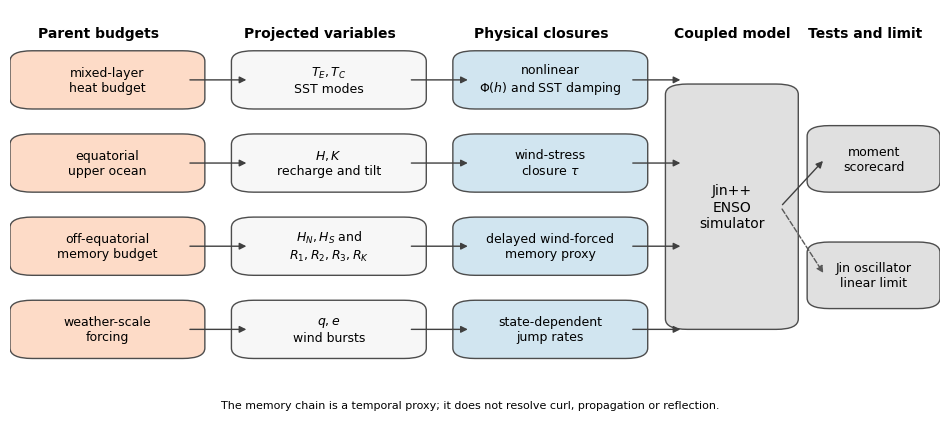

In [17]:
# --- EDIT CONTROLS ---------------------------------------------------------
FIGURE_NAME = "fig_schematic"
FIGURE_TITLE = None  # e.g. "Jin++ model hierarchy"
FIGURE_SIZE = (12.0, 5.4)
FONT_SIZE = 10.0
BOX_COLOURS = {
    "parent": "#fddbc7",
    "variable": "#f7f7f7",
    "closure": "#d1e5f0",
    "result": "#e0e0e0",
}
EDGE_COLOUR = "#4d4d4d"
ARROW_COLOUR = "#404040"
NOTE = "The memory chain is a temporal proxy; it does not resolve curl, propagation or reflection."
# --------------------------------------------------------------------------

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.hashsalt": "corrected-jinpp",
})
fig_schematic, ax = plt.subplots(figsize=FIGURE_SIZE)
ax.set_axis_off()
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1)

def add_box(x, y, width, height, text, facecolour, fontsize=9):
    patch = FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.02,rounding_size=0.025",
        fc=facecolour, ec=EDGE_COLOUR, lw=1.0,
    )
    ax.add_patch(patch)
    ax.text(
        x + width / 2, y + height / 2, text,
        ha="center", va="center", fontsize=fontsize,
    )
    return x, y, width, height

def add_arrow(first, second, linestyle="-", colour=ARROW_COLOUR):
    x1, y1, width1, height1 = first
    x2, y2, _, height2 = second
    ax.add_patch(FancyArrowPatch(
        (x1 + width1, y1 + height1 / 2),
        (x2, y2 + height2 / 2),
        arrowstyle="-|>", mutation_scale=10, lw=1.0,
        color=colour, linestyle=linestyle,
    ))

headings = [
    (0.10, "Parent budgets"),
    (0.35, "Projected variables"),
    (0.60, "Physical closures"),
    (0.815, "Coupled model"),
    (0.965, "Tests and limit"),
]
for x_position, heading in headings:
    ax.text(x_position, 0.96, heading, ha="center", va="top", weight="bold")

y_positions = [0.78, 0.58, 0.38, 0.18]
parents = [
    add_box(0.02, y_positions[0], 0.18, 0.10, "mixed-layer\nheat budget", BOX_COLOURS["parent"]),
    add_box(0.02, y_positions[1], 0.18, 0.10, "equatorial\nupper ocean", BOX_COLOURS["parent"]),
    add_box(0.02, y_positions[2], 0.18, 0.10, "off-equatorial\nmemory budget", BOX_COLOURS["parent"]),
    add_box(0.02, y_positions[3], 0.18, 0.10, "weather-scale\nforcing", BOX_COLOURS["parent"]),
]
variables = [
    add_box(0.27, y_positions[0], 0.18, 0.10, "$T_E,T_C$\nSST modes", BOX_COLOURS["variable"]),
    add_box(0.27, y_positions[1], 0.18, 0.10, "$H,K$\nrecharge and tilt", BOX_COLOURS["variable"]),
    add_box(0.27, y_positions[2], 0.18, 0.10, "$H_N,H_S$ and\n$R_1,R_2,R_3,R_K$", BOX_COLOURS["variable"]),
    add_box(0.27, y_positions[3], 0.18, 0.10, "$q,e$\nwind bursts", BOX_COLOURS["variable"]),
]
closures = [
    add_box(0.52, y_positions[0], 0.18, 0.10, "nonlinear\n$\\Phi(h)$ and SST damping", BOX_COLOURS["closure"]),
    add_box(0.52, y_positions[1], 0.18, 0.10, "wind-stress\nclosure $\\tau$", BOX_COLOURS["closure"]),
    add_box(0.52, y_positions[2], 0.18, 0.10, "delayed wind-forced\nmemory proxy", BOX_COLOURS["closure"]),
    add_box(0.52, y_positions[3], 0.18, 0.10, "state-dependent\njump rates", BOX_COLOURS["closure"]),
]
simulator = add_box(0.76, 0.25, 0.11, 0.55, "Jin++\nENSO\nsimulator", BOX_COLOURS["result"], 10)
score_box = add_box(0.92, 0.58, 0.11, 0.12, "moment\nscorecard", BOX_COLOURS["result"])
limit_box = add_box(0.92, 0.30, 0.11, 0.12, "Jin oscillator\nlinear limit", BOX_COLOURS["result"])

for parent_box, variable_box, closure_box in zip(parents, variables, closures):
    add_arrow(parent_box, variable_box)
    add_arrow(variable_box, closure_box)
    x1, y1, width1, height1 = closure_box
    ax.add_patch(FancyArrowPatch(
        (x1 + width1, y1 + height1 / 2),
        (simulator[0], y1 + height1 / 2),
        arrowstyle="-|>", mutation_scale=10, lw=1.0, color=ARROW_COLOUR,
    ))
add_arrow(simulator, score_box)
add_arrow(simulator, limit_box, linestyle="--", colour="#595959")
ax.text(0.52, 0.04, NOTE, ha="center", fontsize=8)
if FIGURE_TITLE:
    ax.set_title(FIGURE_TITLE)

created_figures[FIGURE_NAME] = fig_schematic
if EXPORT_STATIC:
    for extension in FIGURE_FORMATS:
        metadata = ({"CreationDate": None} if extension == "pdf"
                    else {"Date": None} if extension == "svg" else None)
        fig_schematic.savefig(
            FIGURE_DIR / f"{FIGURE_NAME}.{extension}",
            bbox_inches="tight", dpi=FIGURE_DPI, metadata=metadata,
        )

### Figure 2 — model–observation scorecard

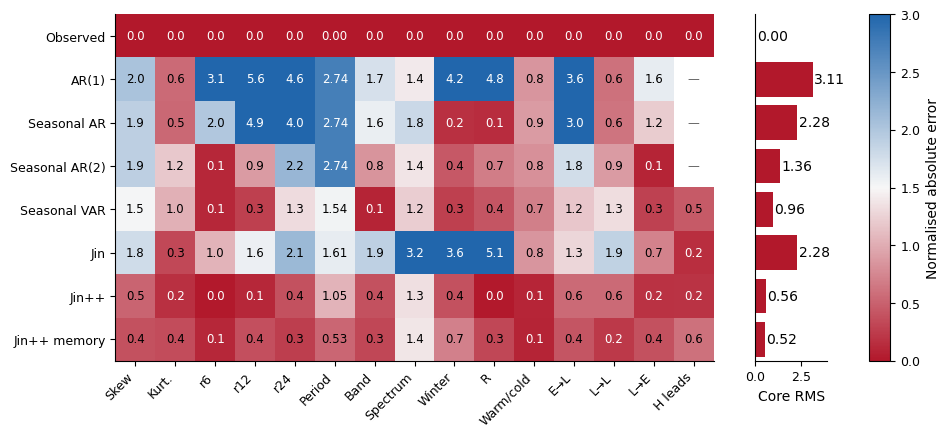

In [18]:
# --- EDIT CONTROLS ---------------------------------------------------------
FIGURE_NAME = "fig_scorecard"
FIGURE_TITLE = None
FIGURE_SIZE = (10.0, 4.5)
FONT_SIZE = 10.0
MODEL_ORDER = [
    "Observed", "AR(1)", "Seasonal AR(1)", "Seasonal AR(2)",
    "Seasonal recharge VAR", "Linear Jin RO",
    "Jin++ (memory off)", "Jin++ (memory on)",
]
MODEL_LABELS = {
    "Seasonal AR(1)": "Seasonal AR",
    "Seasonal recharge VAR": "Seasonal VAR",
    "Linear Jin RO": "Jin",
    "Jin++ (memory off)": "Jin++",
    "Jin++ (memory on)": "Jin++ memory",
}
METRICS = ALL_METRICS
METRIC_LABELS = [
    "Skew", "Kurt.", "r6", "r12", "r24", "Period", "Band", "Spectrum",
    "Winter", "R", "Warm/cold", "E→L", "L→L", "L→E", "H leads",
]
ERROR_COLOURS = ["#b2182b", "#f7f7f7", "#2166ac"]
SCORE_COLOUR = "#b2182b"
ERROR_DISPLAY_LIMIT = 3.0
# --------------------------------------------------------------------------

plt.rcParams.update({
    "font.size": FONT_SIZE, "axes.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE - 1, "xtick.labelsize": FONT_SIZE - 1,
    "ytick.labelsize": FONT_SIZE - 1,
    "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.hashsalt": "corrected-jinpp",
})
error_map = errors.set_index("model").reindex(MODEL_ORDER)
matrix = error_map[METRICS].to_numpy(float)
plot_matrix = np.clip(matrix, 0.0, ERROR_DISPLAY_LIMIT)
score_values = (
    scores.set_index("model")["core_rms_score"]
    .reindex(MODEL_ORDER).to_numpy(float)
)
score_cmap = LinearSegmentedColormap.from_list("scoremap", ERROR_COLOURS)

fig_scorecard = plt.figure(figsize=FIGURE_SIZE)
grid = GridSpec(1, 3, width_ratios=[15, 1.8, 0.55], wspace=0.18)
ax_heatmap = fig_scorecard.add_subplot(grid[0, 0])
image = ax_heatmap.imshow(
    plot_matrix, aspect="auto", cmap=score_cmap,
    vmin=0, vmax=ERROR_DISPLAY_LIMIT,
)
ax_heatmap.set_xticks(np.arange(len(METRIC_LABELS)))
ax_heatmap.set_xticklabels(METRIC_LABELS, rotation=45, ha="right")
ax_heatmap.set_yticks(np.arange(len(MODEL_ORDER)))
ax_heatmap.set_yticklabels([MODEL_LABELS.get(name, name) for name in MODEL_ORDER])
for row_index in range(matrix.shape[0]):
    for column_index in range(matrix.shape[1]):
        value = matrix[row_index, column_index]
        if np.isfinite(value):
            text_colour = (
                "white" if plot_matrix[row_index, column_index] < 0.25
                or plot_matrix[row_index, column_index] > 2.2 else "black"
            )
            label = f"{value:.2f}" if METRICS[column_index] == "period" else f"{value:.1f}"
        else:
            text_colour, label = "#666666", "—"
        ax_heatmap.text(
            column_index, row_index, label,
            ha="center", va="center", fontsize=FONT_SIZE - 1.5,
            color=text_colour,
        )

ax_score = fig_scorecard.add_subplot(grid[0, 1], sharey=ax_heatmap)
ax_score.barh(np.arange(len(MODEL_ORDER)), score_values, color=SCORE_COLOUR)
ax_score.set_xlabel("Core RMS")
ax_score.tick_params(axis="y", left=False, labelleft=False)
score_limit = max(np.nanmax(score_values) * 1.25, 1.0)
ax_score.set_xlim(0, score_limit)
for row_index, value in enumerate(score_values):
    ax_score.text(value + score_limit * 0.02, row_index, f"{value:.2f}", va="center")

colour_axis = fig_scorecard.add_subplot(grid[0, 2])
fig_scorecard.colorbar(image, cax=colour_axis).set_label("Normalised absolute error")
if FIGURE_TITLE:
    fig_scorecard.suptitle(FIGURE_TITLE)

created_figures[FIGURE_NAME] = fig_scorecard
if EXPORT_STATIC:
    for extension in FIGURE_FORMATS:
        metadata = ({"CreationDate": None} if extension == "pdf"
                    else {"Date": None} if extension == "svg" else None)
        fig_scorecard.savefig(
            FIGURE_DIR / f"{FIGURE_NAME}.{extension}",
            bbox_inches="tight", dpi=FIGURE_DPI, metadata=metadata,
        )

### Figure 3 — period-domain spectra

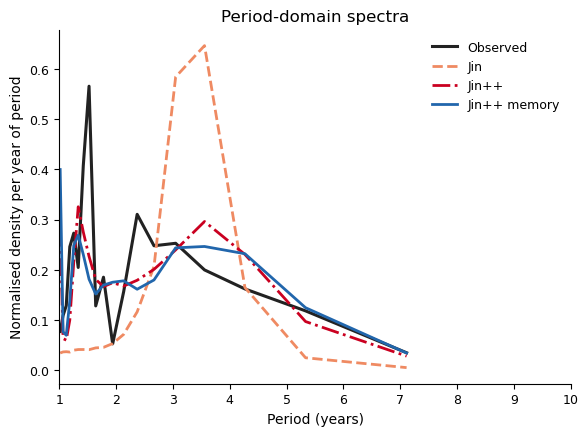

In [19]:
# --- EDIT CONTROLS ---------------------------------------------------------
FIGURE_NAME = "fig_spectrum"
FIGURE_TITLE = "Period-domain spectra"
FIGURE_SIZE = (6.6, 4.6)
FONT_SIZE = 10.0
PERIOD_LIMITS = (1.0, 10.0)  # try (2, 8) to focus on the ENSO band
NORMALISE_AREA = True
MODEL_STYLES = {
    "Observed":            {"label": "Observed",     "colour": "#222222", "linestyle": "-",  "linewidth": 2.2},
    "Linear Jin RO":       {"label": "Jin",          "colour": "#ef8a62", "linestyle": "--", "linewidth": 2.0},
    "Jin++ (memory off)":  {"label": "Jin++",        "colour": "#ca0020", "linestyle": "-.", "linewidth": 2.0},
    "Jin++ (memory on)":   {"label": "Jin++ memory", "colour": "#2166ac", "linestyle": "-",  "linewidth": 2.0},
}
# --------------------------------------------------------------------------

plt.rcParams.update({
    "font.size": FONT_SIZE, "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.hashsalt": "corrected-jinpp",
})
fig_spectrum, ax = plt.subplots(figsize=FIGURE_SIZE)
for model_name, style in MODEL_STYLES.items():
    frame = observations if model_name == "Observed" else models[model_name]
    period, density = spectrum_period(frame["nino34"].to_numpy(float))
    use = (period >= PERIOD_LIMITS[0]) & (period <= PERIOD_LIMITS[1])
    plotted_period = period[use]
    plotted_density = density[use].copy()
    if NORMALISE_AREA:
        plotted_density /= np.trapezoid(plotted_density, plotted_period)
    ax.plot(
        plotted_period, plotted_density,
        color=style["colour"], linestyle=style["linestyle"],
        lw=style["linewidth"], label=style["label"],
    )
ax.set(
    xlim=PERIOD_LIMITS,
    xlabel="Period (years)",
    ylabel=("Normalised density per year of period" if NORMALISE_AREA
            else "Density per year of period"),
    title=FIGURE_TITLE,
)
ax.legend(frameon=False)

created_figures[FIGURE_NAME] = fig_spectrum
if EXPORT_STATIC:
    for extension in FIGURE_FORMATS:
        metadata = ({"CreationDate": None} if extension == "pdf"
                    else {"Date": None} if extension == "svg" else None)
        fig_spectrum.savefig(
            FIGURE_DIR / f"{FIGURE_NAME}.{extension}",
            bbox_inches="tight", dpi=FIGURE_DPI, metadata=metadata,
        )
if not INTERACTIVE_CANVAS:
    display(fig_spectrum)
    plt.close(fig_spectrum)

### Figure 4 — equal-length time-series segments

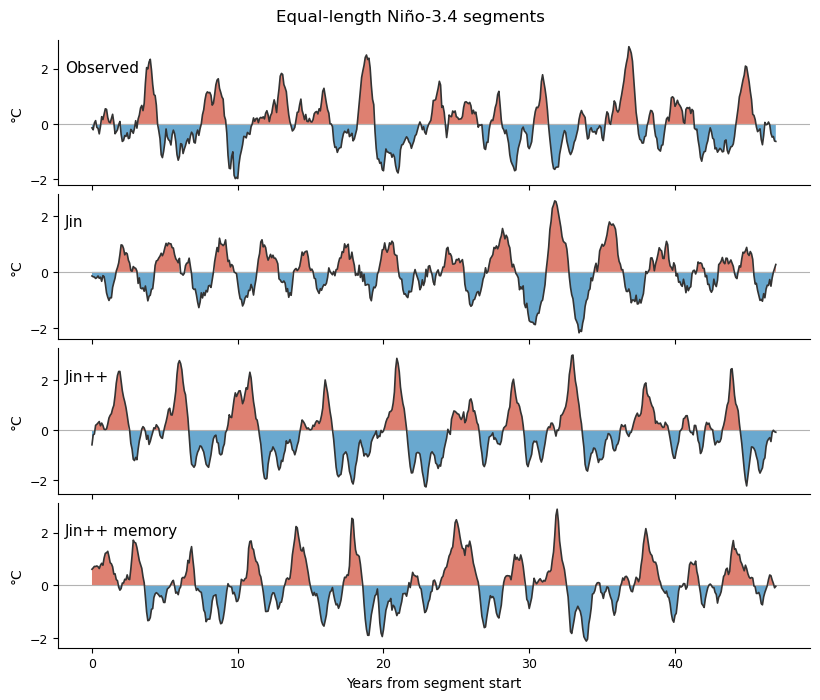

In [20]:
# --- EDIT CONTROLS ---------------------------------------------------------
FIGURE_NAME = "fig_timelines"
FIGURE_TITLE = "Equal-length Niño-3.4 segments"
FIGURE_SIZE = (8.3, 7.1)
FONT_SIZE = 10.0
SEGMENT_MONTHS = len(observations)
PANELS = {
    "Observed":           {"label": "Observed",     "start_month": 0},
    "Linear Jin RO":      {"label": "Jin",          "start_month": 0},
    "Jin++ (memory off)": {"label": "Jin++",        "start_month": 1200},
    "Jin++ (memory on)":  {"label": "Jin++ memory", "start_month": 1800},
}
LINE_COLOUR = "#333333"
WARM_FILL = "#d6604d"
COLD_FILL = "#4393c3"
ZERO_COLOUR = "#b3b3b3"
Y_LIMITS = None  # e.g. (-3, 3) for identical fixed limits
# --------------------------------------------------------------------------

plt.rcParams.update({
    "font.size": FONT_SIZE, "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.hashsalt": "corrected-jinpp",
})
fig_timelines, axes = plt.subplots(
    len(PANELS), 1, figsize=FIGURE_SIZE, sharex=True, squeeze=False,
)
for ax, (model_name, settings) in zip(axes[:, 0], PANELS.items()):
    frame = observations if model_name == "Observed" else models[model_name]
    start = settings["start_month"]
    temperature = frame["nino34"].to_numpy(float)[start:start + SEGMENT_MONTHS]
    years = np.arange(len(temperature)) / 12.0
    ax.axhline(0, color=ZERO_COLOUR, lw=0.8)
    ax.plot(years, temperature, color=LINE_COLOUR, lw=1.2)
    ax.fill_between(
        years, 0, temperature, where=temperature >= 0,
        color=WARM_FILL, alpha=0.8, linewidth=0,
    )
    ax.fill_between(
        years, 0, temperature, where=temperature < 0,
        color=COLD_FILL, alpha=0.8, linewidth=0,
    )
    ax.text(0.01, 0.86, settings["label"], transform=ax.transAxes, va="top", fontsize=11)
    ax.set_ylabel("°C")
    if Y_LIMITS is not None:
        ax.set_ylim(Y_LIMITS)
axes[-1, 0].set_xlabel("Years from segment start")
fig_timelines.suptitle(FIGURE_TITLE)
fig_timelines.tight_layout(h_pad=0.3)

created_figures[FIGURE_NAME] = fig_timelines
if EXPORT_STATIC:
    for extension in FIGURE_FORMATS:
        metadata = ({"CreationDate": None} if extension == "pdf"
                    else {"Date": None} if extension == "svg" else None)
        fig_timelines.savefig(
            FIGURE_DIR / f"{FIGURE_NAME}.{extension}",
            bbox_inches="tight", dpi=FIGURE_DPI, metadata=metadata,
        )
if not INTERACTIVE_CANVAS:
    display(fig_timelines)
    plt.close(fig_timelines)

### Figure 5 — recharge phase space

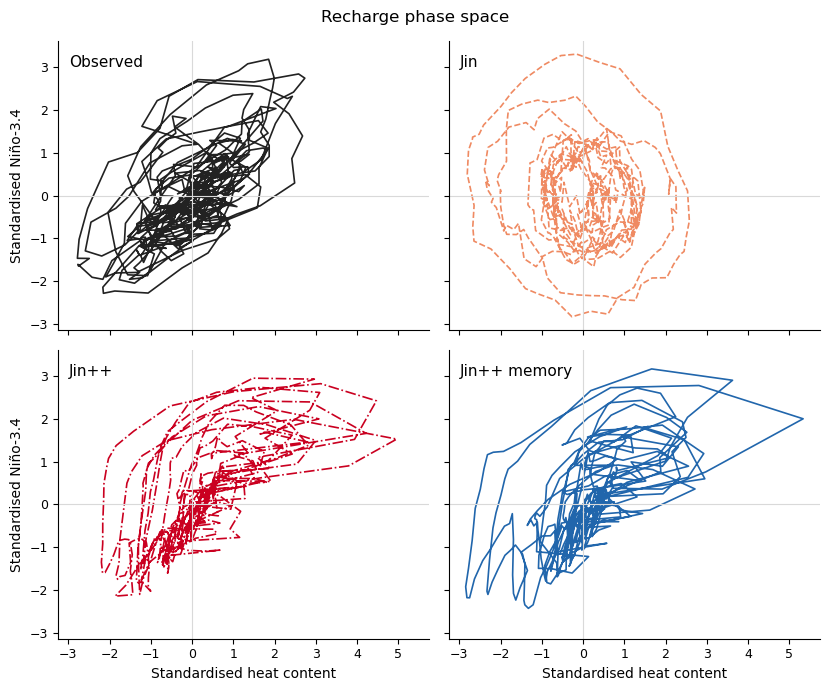

In [21]:
# --- EDIT CONTROLS ---------------------------------------------------------
FIGURE_NAME = "fig_phase_space"
FIGURE_TITLE = "Recharge phase space"
FIGURE_SIZE = (8.4, 7.0)
FONT_SIZE = 10.0
SEGMENT_MONTHS = len(observations)
PANELS = {
    "Observed":           {"label": "Observed",     "start_month": 0,    "colour": "#222222", "linestyle": "-"},
    "Linear Jin RO":      {"label": "Jin",          "start_month": 0,    "colour": "#ef8a62", "linestyle": "--"},
    "Jin++ (memory off)": {"label": "Jin++",        "start_month": 1200, "colour": "#ca0020", "linestyle": "-."},
    "Jin++ (memory on)":  {"label": "Jin++ memory", "start_month": 1800, "colour": "#2166ac", "linestyle": "-"},
}
PANEL_SHAPE = (2, 2)  # keep product equal to the number of PANELS
ZERO_COLOUR = "#d9d9d9"
AXIS_LIMITS = None  # e.g. (-3.5, 3.5)
# --------------------------------------------------------------------------

plt.rcParams.update({
    "font.size": FONT_SIZE, "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.hashsalt": "corrected-jinpp",
})
fig_phase_space, axes = plt.subplots(
    *PANEL_SHAPE, figsize=FIGURE_SIZE, sharex=True, sharey=True, squeeze=False,
)
for ax, (model_name, settings) in zip(axes.flat, PANELS.items()):
    frame = observations if model_name == "Observed" else models[model_name]
    start = settings["start_month"]
    temperature = frame["nino34"].to_numpy(float)[start:start + SEGMENT_MONTHS]
    heat = frame["heat"].to_numpy(float)[start:start + SEGMENT_MONTHS]
    standard_temperature = (temperature - temperature.mean()) / temperature.std()
    standard_heat = (heat - heat.mean()) / heat.std()
    ax.plot(
        standard_heat, standard_temperature,
        color=settings["colour"], linestyle=settings["linestyle"], lw=1.2,
    )
    ax.axhline(0, color=ZERO_COLOUR, lw=0.8)
    ax.axvline(0, color=ZERO_COLOUR, lw=0.8)
    ax.text(0.03, 0.95, settings["label"], transform=ax.transAxes, va="top", fontsize=11)
    if AXIS_LIMITS is not None:
        ax.set(xlim=AXIS_LIMITS, ylim=AXIS_LIMITS)
for ax in axes[:, 0]:
    ax.set_ylabel("Standardised Niño-3.4")
for ax in axes[-1, :]:
    ax.set_xlabel("Standardised heat content")
fig_phase_space.suptitle(FIGURE_TITLE)
fig_phase_space.tight_layout()

created_figures[FIGURE_NAME] = fig_phase_space
if EXPORT_STATIC:
    for extension in FIGURE_FORMATS:
        metadata = ({"CreationDate": None} if extension == "pdf"
                    else {"Date": None} if extension == "svg" else None)
        fig_phase_space.savefig(
            FIGURE_DIR / f"{FIGURE_NAME}.{extension}",
            bbox_inches="tight", dpi=FIGURE_DPI, metadata=metadata,
        )
if not INTERACTIVE_CANVAS:
    display(fig_phase_space)
    plt.close(fig_phase_space)

### Figure 6 — DJF event-state transitions

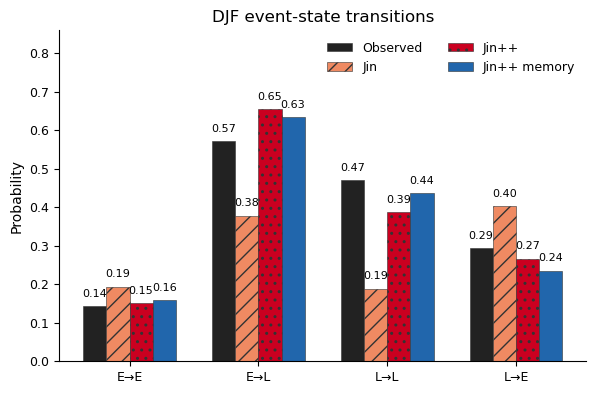

In [22]:
# --- EDIT CONTROLS ---------------------------------------------------------
FIGURE_NAME = "fig_transitions"
FIGURE_TITLE = "DJF event-state transitions"
FIGURE_SIZE = (6.8, 4.3)
FONT_SIZE = 10.0
METRICS = {"E_to_E": "E→E", "E_to_L": "E→L", "L_to_L": "L→L", "L_to_E": "L→E"}
MODEL_STYLES = {
    "Observed":           {"label": "Observed",     "colour": "#222222", "hatch": ""},
    "Linear Jin RO":      {"label": "Jin",          "colour": "#ef8a62", "hatch": "//"},
    "Jin++ (memory off)": {"label": "Jin++",        "colour": "#ca0020", "hatch": ".."},
    "Jin++ (memory on)":  {"label": "Jin++ memory", "colour": "#2166ac", "hatch": ""},
}
BAR_WIDTH = 0.18
Y_LIMITS = (0.0, None)
# --------------------------------------------------------------------------

plt.rcParams.update({
    "font.size": FONT_SIZE, "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.hashsalt": "corrected-jinpp",
})
if "E_to_E" not in statistics.columns:
    # A notebook kernel can retain the pre-E→E table after this cell changes.
    import importlib
    import src.metrics as transition_metrics
    importlib.reload(transition_metrics)
    statistics, errors, scores = transition_metrics.evaluate_models(observations, models)
rows = statistics.set_index("model")
model_names = list(MODEL_STYLES)
metric_names = list(METRICS)
values = rows.loc[model_names, metric_names].to_numpy(float)
positions = np.arange(len(metric_names))

fig_transitions, ax = plt.subplots(figsize=FIGURE_SIZE)
for model_index, model_name in enumerate(model_names):
    style = MODEL_STYLES[model_name]
    x_positions = positions + (model_index - (len(model_names) - 1) / 2) * BAR_WIDTH
    ax.bar(
        x_positions, values[model_index], width=BAR_WIDTH,
        color=style["colour"], hatch=style["hatch"],
        edgecolor="#333333", linewidth=0.4, label=style["label"],
    )
    for x_position, value in zip(x_positions, values[model_index]):
        ax.text(x_position, value + 0.025, f"{value:.2f}", ha="center", fontsize=8)
ax.set_xticks(positions)
ax.set_xticklabels(list(METRICS.values()))
ax.set_ylabel("Probability")
upper_limit = Y_LIMITS[1] or max(0.86, np.nanmax(values) + 0.15)
ax.set_ylim(Y_LIMITS[0], upper_limit)
ax.set_title(FIGURE_TITLE)
ax.legend(frameon=False, ncol=2)

created_figures[FIGURE_NAME] = fig_transitions
if EXPORT_STATIC:
    for extension in FIGURE_FORMATS:
        metadata = ({"CreationDate": None} if extension == "pdf"
                    else {"Date": None} if extension == "svg" else None)
        fig_transitions.savefig(
            FIGURE_DIR / f"{FIGURE_NAME}.{extension}",
            bbox_inches="tight", dpi=FIGURE_DPI, metadata=metadata,
        )

### Figure 7 — fixed-parameter mechanism denials

Both scorecards use the same 15 metrics and tolerances. The ablations use the
same integration length, burn-in, seed, and non-memory parameters as the Jin++
reference runs in Figure 2. Thus **Full model** corresponds to **Jin++ memory**
and **No delayed memory** to **Jin++**; those pairs should have identical
numbers. The other rows each switch off one mechanism without retuning.
`E→E` appears in the transition plot but is not part of either scorecard.
The Period column uses the same fine-grid peak estimate as Figure 2; its
normalised error is shown to two decimals so small differences remain visible.
**No zonal-current SST coupling** removes the current contributions to both
central and eastern SST; the current state and other wind pathways remain.
**Constant-amplitude SST noise** removes SST-dependent amplification of the
direct Gaussian SST noise. Direct SST noise and the separate, seasonally
modulated wind bursts remain active.

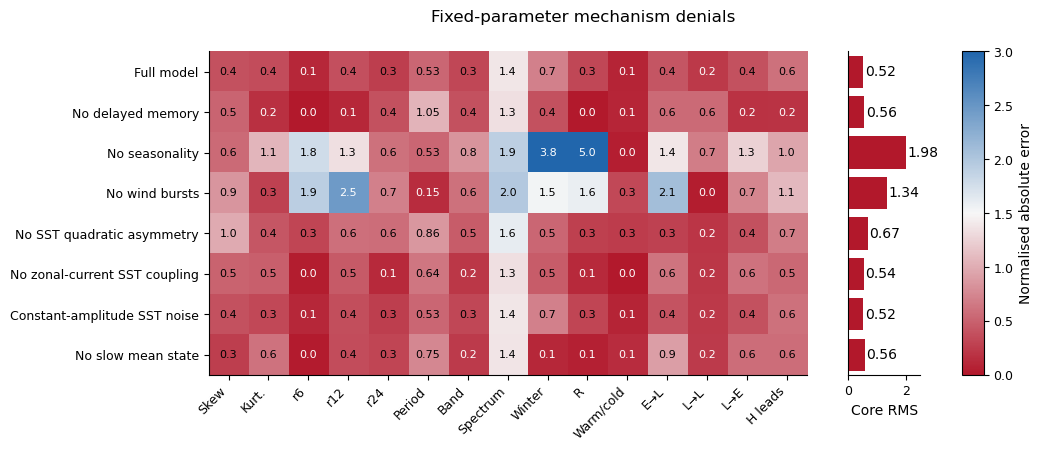

In [23]:
# --- EDIT CONTROLS ---------------------------------------------------------
FIGURE_NAME = "fig_ablations"
FIGURE_TITLE = "Fixed-parameter mechanism denials"
FONT_SIZE = 10.0
ABLATION_ORDER = ablation_errors["model"].tolist()
METRICS = ALL_METRICS
METRIC_LABELS = [
    "Skew", "Kurt.", "r6", "r12", "r24", "Period", "Band", "Spectrum",
    "Winter", "R", "Warm/cold", "E→L", "L→L", "L→E", "H leads",
]
ERROR_COLOURS = ["#b2182b", "#f7f7f7", "#2166ac"]
SCORE_COLOUR = "#b2182b"
ERROR_DISPLAY_LIMIT = 3.0
FIGURE_SIZE = (10.0, max(4.2, 0.42 * len(ABLATION_ORDER)))
# --------------------------------------------------------------------------

plt.rcParams.update({
    "font.size": FONT_SIZE, "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.hashsalt": "corrected-jinpp",
})
matrix = (
    ablation_errors.set_index("model")
    .loc[ABLATION_ORDER, METRICS].to_numpy(float)
)
plot_matrix = np.clip(matrix, 0.0, ERROR_DISPLAY_LIMIT)
score_values = (
    ablation_scores.set_index("model")
    .loc[ABLATION_ORDER, "core_rms_score"].to_numpy(float)
)
score_cmap = LinearSegmentedColormap.from_list("ablation_scoremap", ERROR_COLOURS)

fig_ablations = plt.figure(figsize=FIGURE_SIZE)
grid = GridSpec(1, 3, width_ratios=[15, 1.8, 0.55], wspace=0.18)
ax_heatmap = fig_ablations.add_subplot(grid[0, 0])
image = ax_heatmap.imshow(
    plot_matrix, aspect="auto", cmap=score_cmap,
    vmin=0, vmax=ERROR_DISPLAY_LIMIT,
)
ax_heatmap.set_xticks(np.arange(len(METRIC_LABELS)))
ax_heatmap.set_xticklabels(METRIC_LABELS, rotation=45, ha="right")
ax_heatmap.set_yticks(np.arange(len(ABLATION_ORDER)))
ax_heatmap.set_yticklabels(ABLATION_ORDER)
for row_index in range(matrix.shape[0]):
    for column_index in range(matrix.shape[1]):
        value = matrix[row_index, column_index]
        text_colour = (
            "white" if plot_matrix[row_index, column_index] < 0.25
            or plot_matrix[row_index, column_index] > 2.2 else "black"
        )
        label = f"{value:.2f}" if METRICS[column_index] == "period" else f"{value:.1f}"
        ax_heatmap.text(
            column_index, row_index, label,
            ha="center", va="center", fontsize=8, color=text_colour,
        )

ax_score = fig_ablations.add_subplot(grid[0, 1], sharey=ax_heatmap)
ax_score.barh(np.arange(len(ABLATION_ORDER)), score_values, color=SCORE_COLOUR)
ax_score.set_xlabel("Core RMS")
ax_score.tick_params(axis="y", left=False, labelleft=False)
score_limit = max(np.nanmax(score_values) * 1.25, 1.0)
ax_score.set_xlim(0, score_limit)
for row_index, value in enumerate(score_values):
    ax_score.text(value + score_limit * 0.02, row_index, f"{value:.2f}", va="center")

colour_axis = fig_ablations.add_subplot(grid[0, 2])
fig_ablations.colorbar(image, cax=colour_axis).set_label("Normalised absolute error")
fig_ablations.suptitle(FIGURE_TITLE)

created_figures[FIGURE_NAME] = fig_ablations
if EXPORT_STATIC:
    for extension in FIGURE_FORMATS:
        metadata = ({"CreationDate": None} if extension == "pdf"
                    else {"Date": None} if extension == "svg" else None)
        fig_ablations.savefig(
            FIGURE_DIR / f"{FIGURE_NAME}.{extension}",
            bbox_inches="tight", dpi=FIGURE_DPI, metadata=metadata,
        )

### Figure 8 — delayed-memory strength sensitivity

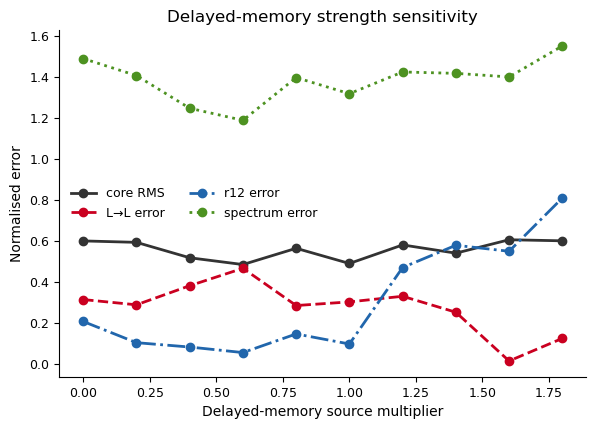

In [24]:
# --- EDIT CONTROLS ---------------------------------------------------------
FIGURE_NAME = "fig_memory_sensitivity"
FIGURE_TITLE = "Delayed-memory strength sensitivity"
FIGURE_SIZE = (6.8, 4.5)
FONT_SIZE = 10.0
LINES = {
    "core_rms_score": {"label": "core RMS",       "scale": 1.00, "colour": "#333333", "linestyle": "-"},
    "L_to_L_error":   {"label": "L→L error",      "scale": 0.15, "colour": "#ca0020", "linestyle": "--"},
    "ac12_error":     {"label": "r12 error",      "scale": 0.12, "colour": "#2166ac", "linestyle": "-."},
    "spectrum_error": {"label": "spectrum error", "scale": 0.45, "colour": "#4d9221", "linestyle": ":"},
}
MEMORY_LIMITS = None  # e.g. (0.0, 1.5)
Y_LIMITS = None
SHOW_REFERENCE_MEMORY = False
REFERENCE_MEMORY = 1.0
# --------------------------------------------------------------------------

plt.rcParams.update({
    "font.size": FONT_SIZE, "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.hashsalt": "corrected-jinpp",
})
fig_memory, ax = plt.subplots(figsize=FIGURE_SIZE)
for column, style in LINES.items():
    ax.plot(
        sensitivity["memory_factor"], sensitivity[column] / style["scale"],
        marker="o", lw=2.0, color=style["colour"],
        linestyle=style["linestyle"], label=style["label"],
    )
if SHOW_REFERENCE_MEMORY:
    ax.axvline(REFERENCE_MEMORY, color="#808080", lw=1.0, linestyle="--", label="reference")
ax.set(
    xlabel="Delayed-memory source multiplier",
    ylabel="Normalised error",
    title=FIGURE_TITLE,
)
if MEMORY_LIMITS is not None:
    ax.set_xlim(MEMORY_LIMITS)
if Y_LIMITS is not None:
    ax.set_ylim(Y_LIMITS)
ax.legend(frameon=False, ncol=2)

created_figures[FIGURE_NAME] = fig_memory
if EXPORT_STATIC:
    for extension in FIGURE_FORMATS:
        metadata = ({"CreationDate": None} if extension == "pdf"
                    else {"Date": None} if extension == "svg" else None)
        fig_memory.savefig(
            FIGURE_DIR / f"{FIGURE_NAME}.{extension}",
            bbox_inches="tight", dpi=FIGURE_DPI, metadata=metadata,
        )

### Figure 9 — heat-content/SST lead–lag correlation

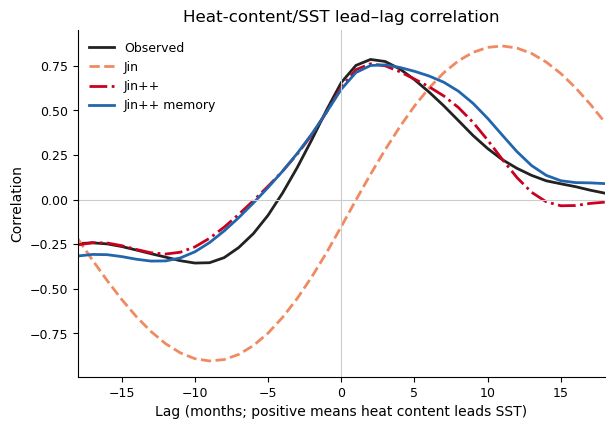

In [25]:
# --- EDIT CONTROLS ---------------------------------------------------------
FIGURE_NAME = "fig_leadlag"
FIGURE_TITLE = "Heat-content/SST lead–lag correlation"
FIGURE_SIZE = (6.8, 4.5)
FONT_SIZE = 10.0
MAX_LAG_MONTHS = 18  # rerun this cell to test another lag window
MODEL_STYLES = {
    "Observed":           {"label": "Observed",     "colour": "#222222", "linestyle": "-"},
    "Linear Jin RO":      {"label": "Jin",          "colour": "#ef8a62", "linestyle": "--"},
    "Jin++ (memory off)": {"label": "Jin++",        "colour": "#ca0020", "linestyle": "-."},
    "Jin++ (memory on)":  {"label": "Jin++ memory", "colour": "#2166ac", "linestyle": "-"},
}
ZERO_COLOUR = "#cccccc"
Y_LIMITS = None
# --------------------------------------------------------------------------

plt.rcParams.update({
    "font.size": FONT_SIZE, "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.hashsalt": "corrected-jinpp",
})
fig_leadlag, ax = plt.subplots(figsize=FIGURE_SIZE)
for model_name, style in MODEL_STYLES.items():
    frame = observations if model_name == "Observed" else models[model_name]
    lags, correlation = lead_lag_correlation(
        frame["heat"].to_numpy(float),
        frame["nino34"].to_numpy(float),
        max_lag=MAX_LAG_MONTHS,
    )
    ax.plot(
        lags, correlation, lw=2.0, color=style["colour"],
        linestyle=style["linestyle"], label=style["label"],
    )
ax.axhline(0, color=ZERO_COLOUR, lw=0.8)
ax.axvline(0, color=ZERO_COLOUR, lw=0.8)
ax.set(
    xlim=(-MAX_LAG_MONTHS, MAX_LAG_MONTHS),
    xlabel="Lag (months; positive means heat content leads SST)",
    ylabel="Correlation",
    title=FIGURE_TITLE,
)
if Y_LIMITS is not None:
    ax.set_ylim(Y_LIMITS)
ax.legend(frameon=False)

created_figures[FIGURE_NAME] = fig_leadlag
if EXPORT_STATIC:
    for extension in FIGURE_FORMATS:
        metadata = ({"CreationDate": None} if extension == "pdf"
                    else {"Date": None} if extension == "svg" else None)
        fig_leadlag.savefig(
            FIGURE_DIR / f"{FIGURE_NAME}.{extension}",
            bbox_inches="tight", dpi=FIGURE_DPI, metadata=metadata,
        )

### Figure 10 — calendar distribution of warm-event peaks

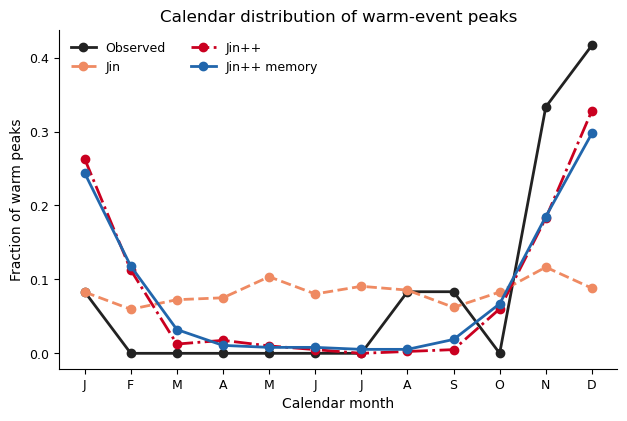

In [26]:
# --- EDIT CONTROLS ---------------------------------------------------------
FIGURE_NAME = "fig_peakmonths"
FIGURE_TITLE = "Calendar distribution of warm-event peaks"
FIGURE_SIZE = (7.2, 4.4)
FONT_SIZE = 10.0
PEAK_THRESHOLD_STD = 0.75
MINIMUM_SEPARATION_MONTHS = 18
MODEL_STYLES = {
    "Observed":           {"label": "Observed",     "colour": "#222222", "linestyle": "-"},
    "Linear Jin RO":      {"label": "Jin",          "colour": "#ef8a62", "linestyle": "--"},
    "Jin++ (memory off)": {"label": "Jin++",        "colour": "#ca0020", "linestyle": "-."},
    "Jin++ (memory on)":  {"label": "Jin++ memory", "colour": "#2166ac", "linestyle": "-"},
}
MONTH_LABELS = list("JFMAMJJASOND")
Y_LIMITS = None
# --------------------------------------------------------------------------

plt.rcParams.update({
    "font.size": FONT_SIZE, "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.hashsalt": "corrected-jinpp",
})
month_centres = np.arange(1, 13)
fig_peakmonths, ax = plt.subplots(figsize=FIGURE_SIZE)
for model_name, style in MODEL_STYLES.items():
    frame = observations if model_name == "Observed" else models[model_name]
    peak_indices = separated_peaks(
        frame["nino34"].to_numpy(float),
        threshold_std=PEAK_THRESHOLD_STD,
        minimum_separation=MINIMUM_SEPARATION_MONTHS,
    )
    peak_calendar_months = peak_indices % 12 + 1
    counts = np.array([
        (peak_calendar_months == month).sum() for month in month_centres
    ], dtype=float)
    fractions = counts / counts.sum()
    ax.plot(
        month_centres, fractions, marker="o", lw=2.0,
        color=style["colour"], linestyle=style["linestyle"], label=style["label"],
    )
ax.set_xticks(month_centres)
ax.set_xticklabels(MONTH_LABELS)
ax.set(
    xlabel="Calendar month",
    ylabel="Fraction of warm peaks",
    title=FIGURE_TITLE,
)
if Y_LIMITS is not None:
    ax.set_ylim(Y_LIMITS)
ax.legend(frameon=False, ncol=2)

created_figures[FIGURE_NAME] = fig_peakmonths
if EXPORT_STATIC:
    for extension in FIGURE_FORMATS:
        metadata = ({"CreationDate": None} if extension == "pdf"
                    else {"Date": None} if extension == "svg" else None)
        fig_peakmonths.savefig(
            FIGURE_DIR / f"{FIGURE_NAME}.{extension}",
            bbox_inches="tight", dpi=FIGURE_DPI, metadata=metadata,
        )

### Figure 11 — common-seed parameter perturbations

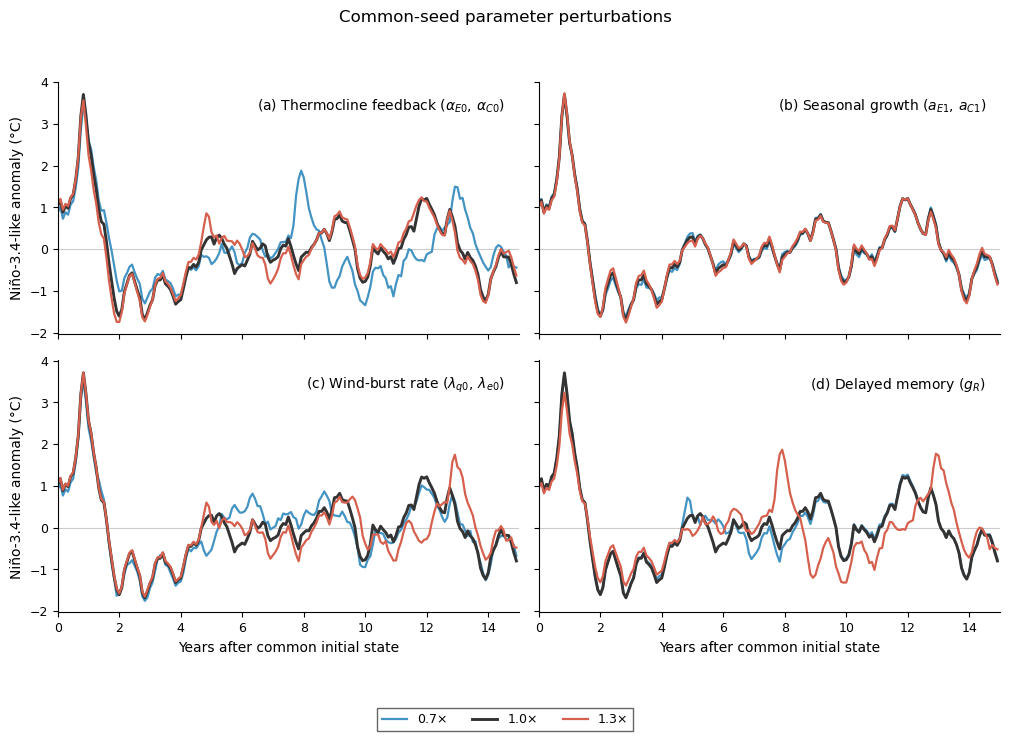

In [27]:
# --- EDIT CONTROLS ---------------------------------------------------------
FIGURE_NAME = "fig_parameter_perturbations"
FIGURE_TITLE = "Common-seed parameter perturbations"
FIGURE_SIZE = (10.2, 7.5)
FONT_SIZE = 10.0
EXPERIMENT_ORDER = [
    "Thermocline feedback", "Seasonal growth",
    "Wind-burst rate", "Delayed memory",
]
EXPERIMENT_TITLES = {
    "Thermocline feedback": r"Thermocline feedback ($\alpha_{E0},\,\alpha_{C0}$)",
    "Seasonal growth": r"Seasonal growth ($a_{E1},\,a_{C1}$)",
    "Wind-burst rate": r"Wind-burst rate ($\lambda_{q0},\,\lambda_{e0}$)",
    "Delayed memory": r"Delayed memory ($g_R$)",
}
FACTOR_STYLES = {
    0.7: {"label": "0.7×", "colour": "#4393c3", "linestyle": "-", "linewidth": 1.6},
    1.0: {"label": "1.0×", "colour": "#333333", "linestyle": "-",  "linewidth": 2.1},
    1.3: {"label": "1.3×", "colour": "#d6604d", "linestyle": "-", "linewidth": 1.6},
}
PANEL_SHAPE = (2, 2)
X_LIMITS = (0, 15)
Y_LIMITS = None
ZERO_COLOUR = "#cccccc"
# --------------------------------------------------------------------------

plt.rcParams.update({
    "font.size": FONT_SIZE, "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.hashsalt": "corrected-jinpp",
})
fig_perturb, axes = plt.subplots(
    *PANEL_SHAPE, figsize=FIGURE_SIZE, sharex=True, sharey=True, squeeze=False,
)
for ax, panel, experiment in zip(axes.flat, "abcd", EXPERIMENT_ORDER):
    experiment_rows = perturbations[perturbations["experiment"] == experiment]
    for factor, style in FACTOR_STYLES.items():
        curve = experiment_rows[np.isclose(experiment_rows["factor"], factor)]
        ax.plot(
            curve["year"], curve["nino34"],
            color=style["colour"], linestyle=style["linestyle"],
            lw=style["linewidth"], label=style["label"],
        )
    ax.axhline(0, color=ZERO_COLOUR, lw=0.8, zorder=0)
    ax.text(
        0.97, 0.94, f"({panel}) {EXPERIMENT_TITLES[experiment]}",
        transform=ax.transAxes, va="top", ha="right",
    )
    if X_LIMITS is not None:
        ax.set_xlim(X_LIMITS)
    if Y_LIMITS is not None:
        ax.set_ylim(Y_LIMITS)
for ax in axes[:, 0]:
    ax.set_ylabel("Niño-3.4-like anomaly (°C)")
for ax in axes[-1, :]:
    ax.set_xlabel("Years after common initial state")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig_perturb.legend(
    handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.01),
    ncol=len(FACTOR_STYLES), frameon=True, framealpha=1.0,
    fancybox=False, edgecolor="#666666",
)
fig_perturb.suptitle(FIGURE_TITLE)
fig_perturb.tight_layout(rect=(0, 0.10, 1, 0.95))

created_figures[FIGURE_NAME] = fig_perturb
if EXPORT_STATIC:
    for extension in FIGURE_FORMATS:
        metadata = ({"CreationDate": None} if extension == "pdf"
                    else {"Date": None} if extension == "svg" else None)
        fig_perturb.savefig(
            FIGURE_DIR / f"{FIGURE_NAME}.{extension}",
            bbox_inches="tight", dpi=FIGURE_DPI, metadata=metadata,
        )

## 10. Export tables, record provenance, and check completeness

In [28]:
if EXPORT_TABLES:
    tables = {
        "jinpp_memory_off_indices.csv": memory_off,
        "jinpp_memory_on_indices.csv": memory_on,
        "model_statistics.csv": statistics,
        "model_normalised_errors.csv": errors,
        "model_scores.csv": scores,
        "ablation_statistics.csv": ablation_statistics,
        "ablation_normalised_errors.csv": ablation_errors,
        "ablation_scores.csv": ablation_scores,
        "memory_sensitivity.csv": sensitivity,
        "parameter_perturbation_trajectories.csv": perturbations,
    }
    for filename, frame in tables.items():
        frame.to_csv(TABLE_DIR / filename, index=False, float_format="%.12g")

    summary = {
        "config": asdict(config),
        "parameter_overrides": PARAMETER_OVERRIDES,
        "experiment_controls": {
            "ablation": {
                "names": ABLATION_NAMES, "years": ABLATION_YEARS,
                "burn": ABLATION_BURN, "dt": ABLATION_DT, "seed": ABLATION_SEED,
            },
            "memory_sensitivity": {
                "factors": MEMORY_FACTORS.tolist(), "years": SENSITIVITY_YEARS,
                "burn": SENSITIVITY_BURN, "dt": SENSITIVITY_DT,
                "seed": SENSITIVITY_SEED,
            },
            "parameter_perturbations": {
                "groups": PERTURBATION_GROUPS, "factors": list(PERTURBATION_FACTORS),
                "years": PERTURBATION_YEARS, "burn": PERTURBATION_BURN,
                "dt": PERTURBATION_DT, "seed": PERTURBATION_SEED,
            },
        },
        "observation_months": len(observations),
        "reference_model_months": analysis_months,
        "figure_count": len(created_figures),
        "best_core_model": scores.query("model != 'Observed'").nsmallest(1, "core_rms_score").iloc[0]["model"],
        "scores": scores.to_dict(orient="records"),
    }
    (TABLE_DIR / "run_summary.json").write_text(json.dumps(summary, indent=2))

generated = sorted(TABLE_DIR.glob("*")) + sorted(FIGURE_DIR.glob("fig_*"))
manifest_rows = []
for path in generated:
    if not path.is_file() or path.name == "reproduction_manifest.csv":
        continue
    manifest_rows.append({
        "file": str(path.relative_to(ROOT)),
        "bytes": path.stat().st_size,
        "sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
    })
manifest = pd.DataFrame(manifest_rows)
manifest.to_csv(TABLE_DIR / "reproduction_manifest.csv", index=False)
manifest.tail()

,file,bytes,sha256
36,output/figures/fig_spectrum.svg,36031,dc2b81df02c5636bed83b0bf2516707959c0b3aa318ed2...
37,output/figures/fig_timelines.pdf,48351,dd06c97e68a8a1561b1d4227fc7e3a83c83771f1b7b4f5...
38,output/figures/fig_timelines.svg,225012,1d687e2f7b419d25eed46cade4e5db6a7a094155d62326...
39,output/figures/fig_transitions.pdf,24387,85cba6c31e381cb67b22507682f442a5440d226f24ce47...
40,output/figures/fig_transitions.svg,108140,16ac7e4bbc1541d2041d1c1e4fa09319a7d8fd6d29dff5...


In [29]:
expected_names = {
    "fig_schematic", "fig_scorecard", "fig_spectrum", "fig_timelines",
    "fig_phase_space", "fig_transitions", "fig_ablations",
    "fig_memory_sensitivity", "fig_leadlag", "fig_peakmonths",
    "fig_parameter_perturbations",
}
assert set(created_figures) == expected_names
assert np.isfinite(memory_on.select_dtypes("number").to_numpy()).all()
assert set(models) == {
    "AR(1)", "Seasonal AR(1)", "Seasonal AR(2)", "Seasonal recharge VAR",
    "Linear Jin RO", "Jin++ (memory off)", "Jin++ (memory on)",
}
if EXPORT_STATIC:
    missing = [
        f"{name}.{extension}"
        for name in expected_names
        for extension in FIGURE_FORMATS
        if not (FIGURE_DIR / f"{name}.{extension}").exists()
    ]
    assert not missing, f"Missing exports: {missing}"

print(f"Checks passed: {len(created_figures)} live figures; "
      f"{len(manifest)} manifested outputs.")

Checks passed: 11 live figures; 41 manifested outputs.


## 11. Monster El Niño events in 50,000-year controls

**Questions:** How large are the biggest warm events? How often does a fixed
Niño-3.4 threshold occur? Which state variables are unusual before and during
the events? This section can run after just setup/configuration and loading
the observations (sections 1–2); it does not need the paper experiments.

Five independent 10,000-year controls per model use the existing equations
and parameters, with 200 years of spin-up each. **Jin** is the exact linear
recharge oscillator; **Jin++** has memory off; **Jin++memory** has memory on.
Their raw temperature units are mapped to observed mean/SD using separate
2,000-year calibration controls, then that mapping is held fixed. The memory
comparison uses identical non-memory parameters; it is not a parameter fit.

**Definitions and limits**

- A warm event is a local maximum of the centred three-month Niño-3.4 mean,
  above the run's mean plus 0.75 monthly SD, separated by at least 18 months,
  exactly as in the existing diagnostics. Months above threshold are not
  counted as independent events. The first/last two monthly centres are
  excluded from the exposure because peak detection needs neighbours.
- Mean event recurrence is $T(u)=Y/N(\mathrm{peak}\geq u)$ years. A 500-year
  event is an event **rate**, not a 500-year clock, and is not exactly an annual
  exceedance probability. Return levels are empirical, without tail extrapolation.
- A model-specific 500-year cutoff selects the rare-event composites. Its
  rarity is **by construction**. The shared historical/2026 temperature
  thresholds instead test how rare the *same amplitude* is in each model.
- The local observations end in 2025. `EVENT_2026_PEAK_C = None` intentionally
  leaves the 2026 amplitude unspecified. Enter a comparable three-month
  anomaly (and its source) below to test the proposed 500-year recurrence;
  a developing event's eventual peak is not yet known from this dataset.
- These are stationary, fixed-parameter model climates, not forecasts or
  evidence that the real 2026 event has a particular return period. Matching
  historical variance does not validate the far tail. Structural, parameter,
  observational, scaling and time-step uncertainties are outside the intervals.

In [30]:
# --- EDIT EXPERIMENT CONTROLS ---------------------------------------------
EXTREME_YEARS_PER_SEED = 10_000   # retained years; independent of MODE
EXTREME_SEEDS = [73100, 73101, 73102, 73103, 73104]
EXTREME_BURN = 200
EXTREME_DT = config.dt
EXTREME_CALIBRATION_YEARS = 2_000
EXTREME_CALIBRATION_SEED = 73000
EXTREME_RETURN_YEARS = 500
EXTREME_SEPARATION_MONTHS = 18
EVENT_2026_PEAK_C = None         # comparable three-month Niño-3.4 mean, °C
EVENT_2026_SOURCE = ""           # series, anomaly baseline, date/forecast provenance
EXTREME_BLOCK_YEARS = 200
EXTREME_BOOTSTRAPS = 400
EXTREME_USE_CACHE = True         # parameter/seed/time-step/source-keyed .npz files
EXTREME_EXPORT = True           # diagnostics plus figures in output/figures
EXTREME_COLOURS = {"Jin": "#555555", "Jin++": "#d17a22", "Jin++memory": "#2166ac"}
# For a machinery check use 250 years/seed and fewer bootstraps; this cannot
# resolve 500-year tails reliably. Defaults retain 50,000 years per model.
# --------------------------------------------------------------------------

from time import perf_counter
from src.extremes import (
    MODEL_NAMES, VARIABLE_LABELS, simulate_control, temperature_mapping,
    event_catalogue, empirical_return_curve, empirical_return_level,
    recurrence_at_threshold, block_return_levels, seasonal_percentiles,
    event_windows, precursor_summary,
)
from src.metrics import three_month_mean
from IPython.display import Markdown

assert len(set(EXTREME_SEEDS)) == len(EXTREME_SEEDS), "Use independent seeds."
assert EXTREME_CALIBRATION_SEED not in EXTREME_SEEDS
assert len(EXTREME_SEEDS) > 0
assert EXTREME_RETURN_YEARS > 0
if EVENT_2026_PEAK_C is not None:
    assert np.isfinite(EVENT_2026_PEAK_C) and EVENT_2026_PEAK_C > 0
    if not EVENT_2026_SOURCE:
        print("2026 amplitude has no source: treat it as a hypothetical scenario.")

EXTREME_DIR = ROOT / "output" / "extremes"
EXTREME_DIR.mkdir(parents=True, exist_ok=True)
EXTREME_FIGURE_DIR = ROOT / "output" / "figures"
EXTREME_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
extreme_cache = EXTREME_DIR / "cache" if EXTREME_USE_CACHE else None
extreme_figures = {}

def save_extreme_figure(figure, stem):
    """Immediately save one extreme-event figure when its cell is run."""
    if not EXTREME_EXPORT:
        return []
    paths = []
    for extension in ("png", "pdf"):
        path = EXTREME_FIGURE_DIR / f"fig_extreme_{stem}.{extension}"
        figure.savefig(path, dpi=160, bbox_inches="tight")
        paths.append(path)
    print("Saved " + ", ".join(str(path.relative_to(ROOT)) for path in paths))
    return paths

print(f"Retained simulation: {len(EXTREME_SEEDS) * EXTREME_YEARS_PER_SEED:,} years/model")

Retained simulation: 50,000 years/model


### Run the controls and check stability across seeds

Every seed is integrated separately; smoothing and event windows never cross
run boundaries. Cached numerical trajectories are reused only when parameters,
seed, length, burn-in, time step, NumPy version and integrator source match.
The table compares the first and second halves and reports a separate 500-year
estimate per seed; differences reveal finite-sample variability or possible drift.

In [31]:
extreme_runs, extreme_mappings, extreme_events = {}, {}, {}
extreme_exposure, extreme_health_rows = {}, []
extreme_started = perf_counter()
for name in MODEL_NAMES:
    calibration = simulate_control(
        name, parameters, years=EXTREME_CALIBRATION_YEARS, burn=EXTREME_BURN,
        dt=EXTREME_DT, seed=EXTREME_CALIBRATION_SEED, cache_dir=extreme_cache,
    )
    extreme_mappings[name] = temperature_mapping(calibration, observations)
    extreme_runs[name], catalogues = {}, []
    for seed in EXTREME_SEEDS:
        raw = simulate_control(
            name, parameters, years=EXTREME_YEARS_PER_SEED, burn=EXTREME_BURN,
            dt=EXTREME_DT, seed=seed, cache_dir=extreme_cache,
        )
        extreme_runs[name][seed] = raw
        events = event_catalogue(raw, extreme_mappings[name], seed=seed,
                                 minimum_separation=EXTREME_SEPARATION_MONTHS)
        catalogues.append(events)
        mapping = extreme_mappings[name]
        temperature = raw.nino34_raw.to_numpy() * mapping["scale"] + mapping["offset"]
        first, second = np.array_split(temperature, 2)
        extreme_health_rows.append({
            "model": name, "seed": seed, "years": len(raw)/12,
            "mean_first_c": first.mean(), "mean_second_c": second.mean(),
            "sd_first_c": first.std(), "sd_second_c": second.std(),
            "warm_events": len(events), "largest_peak_c": events.peak_c.max(),
            "level_500y_c": empirical_return_level(events, (len(raw)-4)/12, 500),
        })
    extreme_events[name] = pd.concat(catalogues, ignore_index=True)
    extreme_exposure[name] = sum((len(raw)-4)/12 for raw in extreme_runs[name].values())
    print(f"{name}: {extreme_exposure[name]:,.1f} eligible years, "
          f"{len(extreme_events[name]):,} warm events; elapsed {perf_counter()-extreme_started:.1f}s")
extreme_health = pd.DataFrame(extreme_health_rows)
display(extreme_health.round(3))
display(pd.DataFrame(extreme_mappings).T.round(4).rename_axis("model"))

Jin: 49,998.3 eligible years, 12,430 warm events; elapsed 0.3s
Jin++: 49,998.3 eligible years, 12,593 warm events; elapsed 1.7s
Jin++memory: 49,998.3 eligible years, 12,049 warm events; elapsed 2.7s


,model,seed,years,mean_first_c,mean_second_c,sd_first_c,sd_second_c,warm_events,largest_peak_c,level_500y_c
0,Jin,73100,10000.0,0.015,0.017,0.868,0.867,2463,3.618,2.733
1,Jin,73101,10000.0,0.013,0.013,0.869,0.856,2503,3.626,2.758
2,Jin,73102,10000.0,0.013,0.014,0.850,0.867,2497,3.603,2.708
3,Jin,73103,10000.0,0.015,0.016,0.828,0.867,2473,3.849,2.640
4,Jin,73104,10000.0,0.012,0.013,0.851,0.857,2494,3.624,2.704
5,Jin++,73100,10000.0,0.029,0.020,0.854,0.859,2512,3.959,3.308
6,Jin++,73101,10000.0,0.022,0.017,0.863,0.862,2536,4.055,3.385
7,Jin++,73102,10000.0,0.020,0.009,0.864,0.869,2499,3.903,3.340
8,Jin++,73103,10000.0,0.007,0.024,0.867,0.859,2551,4.133,3.293
9,Jin++,73104,10000.0,0.021,0.024,0.862,0.863,2495,4.210,3.363


,offset,scale,calibration_raw_mean,calibration_raw_sd
model,,,,
Jin,0.0142,2.0877,-0.0005,0.4182
Jin++,1.0343,2.7985,-0.3649,0.3120
Jin++memory,1.1661,2.8942,-0.3984,0.3017


### Event recurrence and the 500-year amplitude

The first table estimates 100-, 500- and 1,000-year event amplitudes; 95% bands
resample **200-year time blocks**, retaining event clusters within a block.
The second table uses common, fixed amplitude thresholds and gives approximate
95% Poisson count intervals for recurrence. These assume a constant rare-event
rate; clustering can invalidate them. For zero events, the point estimate is
unresolved and only a one-sided lower bound is reported, not “impossible”.
Bootstrap bounds are withheld if fewer than 95% of replicates resolve the
requested level; `bootstrap_valid` reports that check.
The count-interval formula follows the [NIST Poisson-process treatment](https://www.itl.nist.gov/div898/handbook/apr/section4/apr451.htm).

The observed-record maximum is a comparison level, not an observed 500-year
estimate. The roughly 47-year input cannot independently identify such a tail.

In [32]:
observed_smooth, observed_centres = three_month_mean(observations.nino34.to_numpy())
observed_largest = int(np.argmax(observed_smooth))
observed_record_peak = float(observed_smooth[observed_largest])
observed_record_date = observations.date.iloc[observed_centres[observed_largest]]
extreme_thresholds = {"1979–2025 record peak": observed_record_peak}
if EVENT_2026_PEAK_C is not None:
    extreme_thresholds["2026 supplied amplitude"] = float(EVENT_2026_PEAK_C)

extreme_periods = np.unique([10, 20, 50, 100, 200, EXTREME_RETURN_YEARS, 1000, 2000, 5000])
extreme_level_tables, extreme_recurrence_rows = [], []
extreme_cutoffs = {}
for name in MODEL_NAMES:
    events, exposure = extreme_events[name], extreme_exposure[name]
    levels = block_return_levels(
        events, {seed: len(raw) for seed, raw in extreme_runs[name].items()},
        extreme_periods, block_years=EXTREME_BLOCK_YEARS,
        draws=EXTREME_BOOTSTRAPS, seed=90210,
    )
    levels.insert(0, "model", name)
    extreme_level_tables.append(levels)
    extreme_cutoffs[name] = empirical_return_level(events, exposure, EXTREME_RETURN_YEARS)
    for label, threshold in extreme_thresholds.items():
        extreme_recurrence_rows.append({"model": name, "comparison": label,
            **recurrence_at_threshold(events, exposure, threshold)})
extreme_levels = pd.concat(extreme_level_tables, ignore_index=True)
extreme_recurrence = pd.DataFrame(extreme_recurrence_rows)
print(f"Observed record three-month peak: {observed_record_peak:.3f} °C, centred {observed_record_date:%Y-%m}")
display(extreme_levels[extreme_levels.return_years.isin([100, EXTREME_RETURN_YEARS, 1000])].round(3))
display(extreme_recurrence.round(2))
if (extreme_levels.expected_exceedances < 20).any():
    print("Levels supported by fewer than 20 expected events are especially uncertain.")
if EVENT_2026_PEAK_C is None:
    print("2026 recurrence is not evaluated: enter EVENT_2026_PEAK_C above.")

Observed record three-month peak: 2.683 °C, centred 2015-12


,model,return_years,level_c,low_c,high_c,bootstrap_valid,bootstrap_draws,blocks,expected_exceedances
3,Jin,100,2.260,2.224,2.306,400,400,250,499.983
5,Jin,500,2.700,2.661,2.752,400,400,250,99.997
6,Jin,1000,2.884,2.814,2.974,400,400,250,49.998
12,Jin++,100,2.888,2.860,2.914,400,400,250,499.983
14,Jin++,500,3.333,3.291,3.370,400,400,250,99.997
15,Jin++,1000,3.514,3.441,3.563,400,400,250,49.998
21,Jin++memory,100,2.984,2.955,3.010,400,400,250,499.983
23,Jin++memory,500,3.450,3.406,3.504,400,400,250,99.997
24,Jin++memory,1000,3.635,3.551,3.707,400,400,250,49.998


,model,comparison,threshold_c,events,exposure_years,return_years,return_low,return_high,interval
0,Jin,1979–2025 record peak,2.68,108,49998.33,462.95,383.44,564.35,Poisson 95% two-sided
1,Jin++,1979–2025 record peak,2.68,877,49998.33,57.01,53.36,60.98,Poisson 95% two-sided
2,Jin++memory,1979–2025 record peak,2.68,1068,49998.33,46.81,44.09,49.75,Poisson 95% two-sided


Levels supported by fewer than 20 expected events are especially uncertain.
2026 recurrence is not evaluated: enter EVENT_2026_PEAK_C above.


Saved output/figures/fig_extreme_return_levels.png, output/figures/fig_extreme_return_levels.pdf


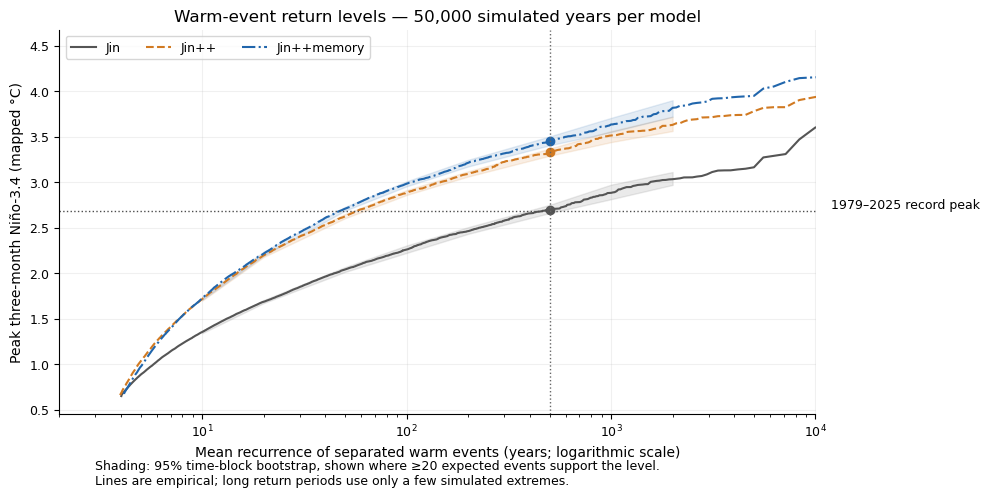

In [33]:
# --- EDIT PLOT CONTROLS ---------------------------------------------------
EXTREME_RETURN_FIGSIZE = (10, 4.8)
EXTREME_MAX_PLOT_RETURN = 10_000
# --------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=EXTREME_RETURN_FIGSIZE)
for name, style in zip(MODEL_NAMES, ["-", "--", "-."]):
    curve = empirical_return_curve(extreme_events[name], extreme_exposure[name])
    ax.plot(curve.return_years, curve.level_c, style, color=EXTREME_COLOURS[name], label=name)
    supported = extreme_levels.query("model == @name and expected_exceedances >= 20")
    ax.fill_between(supported.return_years, supported.low_c, supported.high_c,
                    color=EXTREME_COLOURS[name], alpha=.12)
    ax.plot(EXTREME_RETURN_YEARS, extreme_cutoffs[name], "o", color=EXTREME_COLOURS[name])
for label, threshold in extreme_thresholds.items():
    ax.axhline(threshold, color="0.3", ls=":", lw=1)
    ax.text(1.02, threshold, label, fontsize=9, va="bottom", transform=ax.get_yaxis_transform())
ax.axvline(EXTREME_RETURN_YEARS, color="0.4", ls=":", lw=1)
ax.set(xscale="log", xlim=(2, EXTREME_MAX_PLOT_RETURN),
       xlabel="Mean recurrence of separated warm events (years; logarithmic scale)",
       ylabel="Peak three-month Niño-3.4 (mapped °C)",
       title=f"Warm-event return levels — {len(EXTREME_SEEDS)*EXTREME_YEARS_PER_SEED:,} simulated years per model")
ax.legend(loc="upper left", ncol=3)
ax.grid(alpha=.18)
fig.text(.1, -.02, "Shading: 95% time-block bootstrap, shown where ≥20 expected events support the level.\n"
         "Lines are empirical; long return periods use only a few simulated extremes.", fontsize=9)
fig.tight_layout()
extreme_figures["return_levels"] = fig
save_extreme_figure(fig, "return_levels")
if not INTERACTIVE_CANVAS:
    display(fig)
    plt.close(fig)

### Life cycles of the 1-in-500-year event cohort

Each model contributes the 100 largest complete event windows: 50,000 retained
years divided by a 500-year event recurrence. Because the warm-event catalogue
contains roughly one event every four years, this is approximately the upper
0.8% of warm events (about the 99.2nd percentile), rather than exactly the
upper 1%. This event-rate definition preserves the intended 1-in-500-year
cohort and supplies 100 members per model.

Events are aligned on their own three-month SST peak. The nested shading shows
the full range, 10th--90th percentile range and interquartile range across the
100 rare events. Lines show the rare-event median, the single event with the
largest peak and the mean of all warm events under the notebook's usual
0.75-standard-deviation, 18-month-separation definition. These are simulated
years, not historical dates.

,model,complete_warm_events,tail_members,warm_event_percentile,tail_cutoff_c,largest_peak_c
0,Jin,12425,100,99.195,2.700,3.849
1,Jin++,12588,100,99.206,3.333,4.210
2,Jin++memory,12045,100,99.170,3.450,4.484


Saved output/figures/fig_extreme_event_lifecycles.png, output/figures/fig_extreme_event_lifecycles.pdf


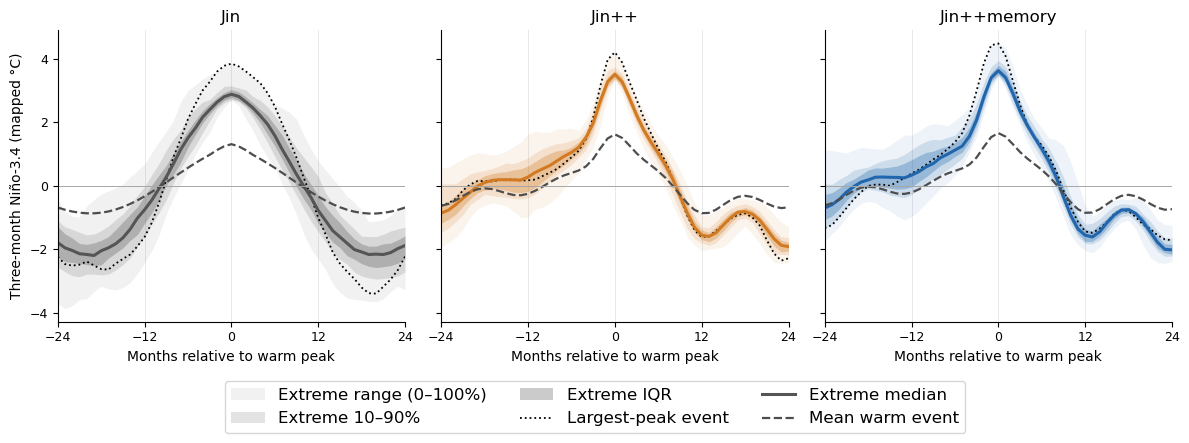

In [41]:
# --- EDIT PLOT CONTROLS ---------------------------------------------------
EXTREME_EVENT_HALF_WIDTH = 24
# --------------------------------------------------------------------------
extreme_lifecycle_rows, extreme_lifecycle_summaries = [], []
extreme_lifecycle_data = {}
event_lags = np.arange(-EXTREME_EVENT_HALF_WIDTH, EXTREME_EVENT_HALF_WIDTH + 1)

for name in MODEL_NAMES:
    complete_events, complete_curves = [], []
    mapping = extreme_mappings[name]
    for event in extreme_events[name].itertuples(index=False):
        raw = extreme_runs[name][event.seed]
        temperature = raw.nino34_raw.to_numpy() * mapping["scale"] + mapping["offset"]
        smooth, centres = three_month_mean(temperature)
        lag = centres - event.month_index
        select = (lag >= -EXTREME_EVENT_HALF_WIDTH) & (lag <= EXTREME_EVENT_HALF_WIDTH)
        if select.sum() != len(event_lags) or not np.array_equal(lag[select], event_lags):
            continue
        complete_events.append(event._asdict())
        complete_curves.append(smooth[select])

    complete_events = pd.DataFrame(complete_events)
    complete_curves = np.stack(complete_curves)
    order = np.argsort(complete_events.peak_c.to_numpy())[::-1]
    target_members = max(1, int(round(extreme_exposure[name] / EXTREME_RETURN_YEARS)))
    target_members = min(target_members, len(order))
    tail_order = order[:target_members]
    tail_events = complete_events.iloc[tail_order].copy().reset_index(drop=True)
    tail_events.insert(0, "rank", np.arange(1, len(tail_events) + 1))
    tail_events.insert(0, "model", name)
    tail_curves = complete_curves[tail_order]
    quantiles = np.quantile(tail_curves, [0, .10, .25, .50, .75, .90, 1], axis=0)
    extreme_lifecycle_data[name] = {
        "tail": tail_curves,
        "quantiles": quantiles,
        "maximum": tail_curves[0],
        "warm_mean": complete_curves.mean(axis=0),
    }
    extreme_lifecycle_rows.append(tail_events)
    extreme_lifecycle_summaries.append({
        "model": name,
        "complete_warm_events": len(complete_events),
        "tail_members": len(tail_events),
        "warm_event_percentile": 100 * (1 - len(tail_events) / len(complete_events)),
        "tail_cutoff_c": tail_events.peak_c.min(),
        "largest_peak_c": tail_events.peak_c.max(),
    })

extreme_lifecycle_events = pd.concat(extreme_lifecycle_rows, ignore_index=True)
extreme_lifecycle_summary = pd.DataFrame(extreme_lifecycle_summaries)
display(extreme_lifecycle_summary.round(3))

fig, axes = plt.subplots(1, 3, figsize=(12, 4.8), sharex=True, sharey=True)
for ax, name in zip(axes, MODEL_NAMES):
    values = extreme_lifecycle_data[name]
    q0, q10, q25, q50, q75, q90, q100 = values["quantiles"]
    colour = EXTREME_COLOURS[name]
    ax.fill_between(event_lags, q0, q100, color=colour, alpha=.08, linewidth=0,
                    label="Extreme range (0–100%)")
    ax.fill_between(event_lags, q10, q90, color=colour, alpha=.16, linewidth=0,
                    label="Extreme 10–90%")
    ax.fill_between(event_lags, q25, q75, color=colour, alpha=.30, linewidth=0,
                    label="Extreme IQR")
    ax.plot(event_lags, values["maximum"], color="black", lw=1.3, ls=":",
            label="Largest-peak event")
    ax.plot(event_lags, q50, color=colour, lw=2.2, label="Extreme median")
    ax.plot(event_lags, values["warm_mean"], color="0.30", lw=1.6, ls="--",
            label="Mean warm event")
    ax.axhline(0, color="0.65", lw=.7)
    ax.set_axisbelow(True)
    ax.set_xticks(np.arange(-EXTREME_EVENT_HALF_WIDTH, EXTREME_EVENT_HALF_WIDTH + 1, 12))
    ax.grid(axis="x", color="0.75", lw=.7, alpha=.35)
    ax.set(title=name, xlabel="Months relative to warm peak",
           xlim=(-EXTREME_EVENT_HALF_WIDTH, EXTREME_EVENT_HALF_WIDTH))
axes[0].set_ylabel("Three-month Niño-3.4 (mapped °C)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(.5, .01),
           ncol=3, frameon=True, fontsize=12)
#fig.suptitle(f"Life cycles of the {EXTREME_RETURN_YEARS}-year warm-event tail "
#             f"({len(extreme_lifecycle_data[MODEL_NAMES[0]]['tail'])} members per model)")
fig.tight_layout(rect=(0, .14, 1, .94))
extreme_figures["event_lifecycles"] = fig
save_extreme_figure(fig, "event_lifecycles")
if not INTERACTIVE_CANVAS:
    display(fig)
    plt.close(fig)

### Which model variables become extreme?

Each variable is converted to its percentile among **all retained months of
the same calendar month, in the same model**, pooled across seeds. This
handles different units, skewness and seasonality. Ties use midranks; constant
memory states in Jin++ are omitted. Values are coherent end-of-month states,
except burst inputs, which are totals during that month. Labels describe model
proxies: e.g. `K` is a fast wind filter, not a resolved Kelvin wave.
The heat-content proxy combines `H`, `K`, wind forcing, off-equatorial recharge
and `R3`; it can rise while equatorial recharge `H` falls. Percentiles describe
relative rank, not sign: a high memory percentile can mean a less negative state.

`EXTREME_COMPOSITE_MODE = "return_level"` selects each model's own 500-year
tail. Switch to `"observed_record"` or `"2026"` to compare equal-amplitude
cohorts. “Ordinary warm events” lie below the chosen cutoff. The analysis
includes negative extremes because recharge/memory depletion may matter as
much as high values. A percentile of 50 is ordinary; 95–100 is the upper tail;
0–5 is the lower tail.

The main heatmap shows Jin++memory only. Colour is retained where a two-sided
Mann--Whitney comparison with ordinary warm events passes a whole-panel
Benjamini--Hochberg false-discovery-rate threshold of 0.05 and has absolute
rank-biserial correlation of at least 0.20. Black dots require the significant
extreme-event median to reach the upper or lower 1% of its same-month
distribution. The nonlinear colour normalisation is symmetric about percentile
50 and keeps moderate percentiles near the neutral colour.

These are **retrospective associations conditioned on a future SST peak**,
not causal drivers or verified warning signals. The event-level test is
descriptive and does not account for residual dependence between nearby event
windows. Peak-centred smoothing uses one future month. High SST near an
SST-selected event is expected; comparison with ordinary warm events gives
additional context.

In [35]:
# --- EDIT COMPOSITE CONTROLS ---------------------------------------------
EXTREME_COMPOSITE_MODE = "return_level"  # "return_level", "observed_record", "2026"
EXTREME_LEAD_MONTHS = 24
EXTREME_AFTER_MONTHS = 12
# --------------------------------------------------------------------------
if EXTREME_COMPOSITE_MODE not in {"return_level", "observed_record", "2026"}:
    raise ValueError("Unknown composite mode")
if EXTREME_COMPOSITE_MODE == "2026" and EVENT_2026_PEAK_C is None:
    raise ValueError("Set EVENT_2026_PEAK_C before selecting the 2026 cohort")
if EXTREME_LEAD_MONTHS < 12 or EXTREME_AFTER_MONTHS < 1:
    raise ValueError("Keep at least 12 lead months and 1 following month for the summary windows")

extreme_composites, extreme_precursor_tables, extreme_cohort_rows = {}, [], []
for name in MODEL_NAMES:
    percentile_runs, omitted = seasonal_percentiles(extreme_runs[name])
    events = extreme_events[name]
    cutoff = (extreme_cutoffs[name] if EXTREME_COMPOSITE_MODE == "return_level" else
              observed_record_peak if EXTREME_COMPOSITE_MODE == "observed_record" else EVENT_2026_PEAK_C)
    selected = events[events.peak_c >= cutoff]
    ordinary = events[events.peak_c < cutoff]
    monster, lags, variables, kept = event_windows(
        percentile_runs, selected, before=EXTREME_LEAD_MONTHS, after=EXTREME_AFTER_MONTHS)
    ordinary_array, _, _, ordinary_kept = event_windows(
        percentile_runs, ordinary, before=EXTREME_LEAD_MONTHS, after=EXTREME_AFTER_MONTHS)
    extreme_composites[name] = {"monster": monster, "ordinary": ordinary_array,
                              "lags": lags, "variables": variables, "events": kept}
    summary = precursor_summary(monster, ordinary_array, lags, variables)
    if not summary.empty:
        extreme_precursor_tables.append(summary.assign(model=name))
    extreme_cohort_rows.append({"model": name, "cutoff_c": cutoff,
        "selected_events": len(selected), "complete_windows": len(kept),
        "ordinary_windows": len(ordinary_kept), "omitted_constant_states": ", ".join(omitted)})
    del percentile_runs
extreme_cohorts = pd.DataFrame(extreme_cohort_rows)
extreme_precursors = pd.concat(extreme_precursor_tables, ignore_index=True) if extreme_precursor_tables else pd.DataFrame()
display(extreme_cohorts.round(3))

,model,cutoff_c,selected_events,complete_windows,ordinary_windows,omitted_constant_states
0,Jin,2.700,99,99,12327,
1,Jin++,3.333,99,99,12491,"memory_source, memory_1, memory_2, memory_retu..."
2,Jin++memory,3.450,99,99,11946,


Saved output/figures/fig_extreme_state_percentiles.png, output/figures/fig_extreme_state_percentiles.pdf


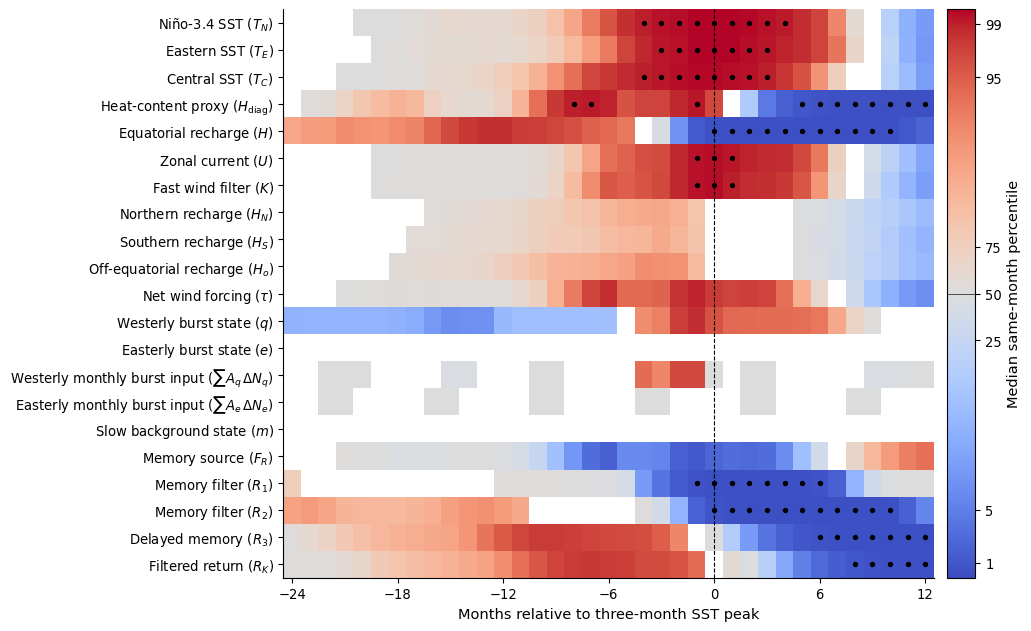

In [39]:
# --- EDIT PLOT CONTROLS ---------------------------------------------------
EXTREME_STATE_MODEL = "Jin++memory"
EXTREME_HEATMAP_SIZE = (10.2, 6.2)
EXTREME_HEATMAP_CMAP = "coolwarm"  # grey centre; blue/red tails
EXTREME_HEATMAP_GAMMA = 2.6      # broad neutral centre; saturated bookend tails
EXTREME_STATE_FDR = 0.05
EXTREME_STATE_MIN_EFFECT = 0.20  # absolute rank-biserial correlation
EXTREME_DOT_PERCENTILE = 99
# --------------------------------------------------------------------------
from matplotlib.colors import FuncNorm
from scipy.stats import mannwhitneyu

composite = extreme_composites[EXTREME_STATE_MODEL]
windows = composite["monster"]
ordinary_windows = composite["ordinary"]
variables = composite["variables"]
lags = composite["lags"]
if not len(windows) or not len(ordinary_windows):
    raise ValueError("Extreme and ordinary warm-event windows are both required")

# Compare event-level distributions at each state/lag cell. The ordinary-event
# comparison accounts for changes that are typical around any warm event.
median = np.median(windows, axis=0).T
ordinary_median = np.median(ordinary_windows, axis=0).T
p_values = np.ones_like(median, dtype=float)
rank_biserial = np.zeros_like(median, dtype=float)
for row in range(len(variables)):
    for col in range(len(lags)):
        extreme_values = windows[:, col, row]
        ordinary_values = ordinary_windows[:, col, row]
        result = mannwhitneyu(
            extreme_values, ordinary_values, alternative="two-sided", method="asymptotic"
        )
        p_values[row, col] = result.pvalue
        rank_biserial[row, col] = (
            2 * result.statistic / (len(extreme_values) * len(ordinary_values)) - 1
        )

# Benjamini--Hochberg false-discovery-rate correction across the whole panel.
flat_p = p_values.ravel()
order = np.argsort(flat_p)
ordered_p = flat_p[order]
ordered_q = ordered_p * len(flat_p) / np.arange(1, len(flat_p) + 1)
ordered_q = np.minimum.accumulate(ordered_q[::-1])[::-1]
flat_q = np.empty_like(flat_p)
flat_q[order] = np.clip(ordered_q, 0, 1)
fdr_q = flat_q.reshape(p_values.shape)
significant = (
    (fdr_q < EXTREME_STATE_FDR)
    & (np.abs(rank_biserial) >= EXTREME_STATE_MIN_EFFECT)
)

# A symmetric power transform preserves 50 as the visual midpoint while keeping
# moderate percentiles pale and reserving saturated colours for the tails.
def percentile_colour_forward(values):
    values = np.ma.asarray(values)
    centred = np.ma.clip((values - 50) / 50, -1, 1)
    return .5 + .5 * np.sign(centred) * np.ma.abs(centred) ** EXTREME_HEATMAP_GAMMA

def percentile_colour_inverse(values):
    values = np.ma.asarray(values)
    centred = 2 * values - 1
    return 50 + 50 * np.sign(centred) * np.ma.abs(centred) ** (1 / EXTREME_HEATMAP_GAMMA)

colour_norm = FuncNorm(
    (percentile_colour_forward, percentile_colour_inverse), vmin=0, vmax=100
)
colour_map = plt.get_cmap(EXTREME_HEATMAP_CMAP).copy()
colour_map.set_bad("white")
plotted = np.ma.masked_where(~significant, median)

fig, ax = plt.subplots(figsize=EXTREME_HEATMAP_SIZE, layout="constrained")
mesh = ax.imshow(
    plotted, origin="upper", aspect="auto", cmap=colour_map, norm=colour_norm,
    extent=(lags[0] - .5, lags[-1] + .5, len(variables) - .5, -.5),
)
ax.set_yticks(range(len(variables)), [VARIABLE_LABELS[v] for v in variables], fontsize=9.5)
ax.set_xticks(np.arange(-EXTREME_LEAD_MONTHS, EXTREME_AFTER_MONTHS + 1, 6))
ax.tick_params(axis="x", labelsize=9.5)
ax.axvline(0, color="black", ls="--", lw=.8)
ax.set_xlabel("Months relative to three-month SST peak", fontsize=10.5)
dot_limit = 100 - EXTREME_DOT_PERCENTILE
dot_rows, dot_cols = np.where(
    significant & ((median >= EXTREME_DOT_PERCENTILE) | (median <= dot_limit))
)
ax.scatter(lags[dot_cols], dot_rows, s=8, c="black")
colour_bar = fig.colorbar(
    mesh, ax=ax, ticks=[1, 5, 25, 50, 75, 95, 99], pad=.02,
    label="Median same-month percentile",
)
colour_bar.ax.tick_params(labelsize=9.5)
colour_bar.set_label("Median same-month percentile", fontsize=10.5)
colour_bar.ax.axhline(50, color="0.30", lw=.7)

extreme_state_significance = pd.DataFrame([
    {
        "model": EXTREME_STATE_MODEL,
        "variable": variable,
        "label": VARIABLE_LABELS.get(variable, variable),
        "lag_months": int(lag),
        "extreme_median_percentile": median[row, col],
        "ordinary_median_percentile": ordinary_median[row, col],
        "p_value": p_values[row, col],
        "fdr_q": fdr_q[row, col],
        "rank_biserial": rank_biserial[row, col],
        "plotted": bool(significant[row, col]),
        "dot_upper_or_lower_1pct": bool(
            significant[row, col]
            and (median[row, col] >= EXTREME_DOT_PERCENTILE
                 or median[row, col] <= dot_limit)
        ),
    }
    for row, variable in enumerate(variables)
    for col, lag in enumerate(lags)
])

extreme_figures["state_percentiles"] = fig
save_extreme_figure(fig, "state_percentiles")
if not INTERACTIVE_CANVAS:
    display(fig)
    plt.close(fig)

### Tail occupancy before and during the events

For three predeclared windows, the table gives the fraction of event-months
above the usual 95th percentile and below the 5th percentile. These are
occupancy fractions, **not the probability of at least one excursion**.
Ordinary warm-event fractions use the identical calculation. The plot ranks
non-SST variables by excess two-tail occupancy in the six months before the
peak, then shows upper and lower tails separately. This ranking is descriptive;
it is not a multiple-testing significance assessment.

Saved output/figures/fig_extreme_precursor_tail_occupancy.png, output/figures/fig_extreme_precursor_tail_occupancy.pdf


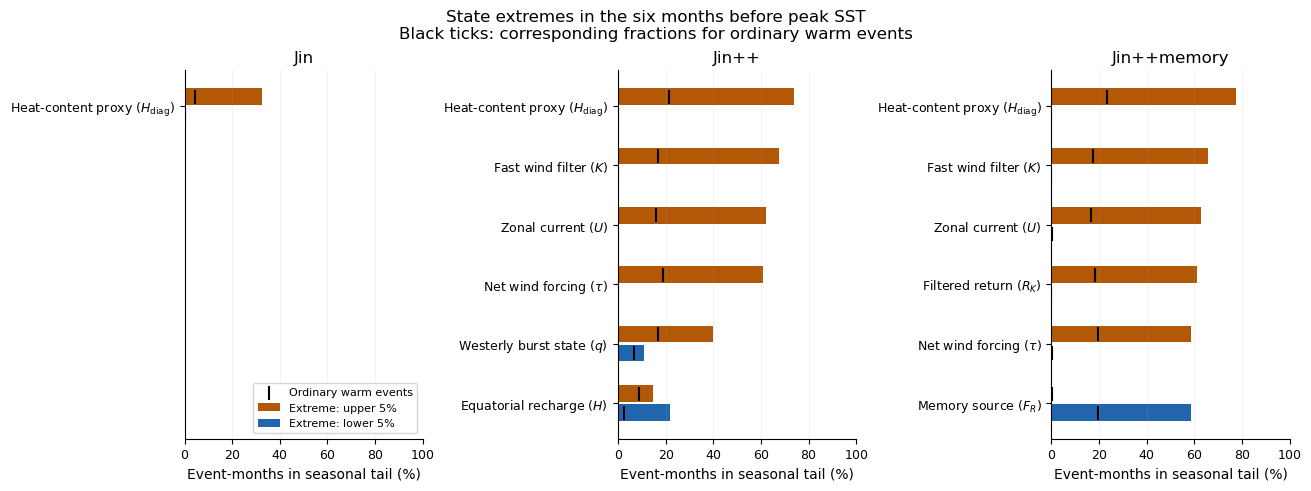

,Model,Window,Variable,Events,Median percentile,Upper 5% (%),Lower 5% (%),Ordinary upper (%),Ordinary lower (%)
1,Jin,12–7 months before,Heat-content proxy ($H_{\mathrm{diag}}$),99,99.7,97.6,0.0,20.2,0.0
3,Jin,6–1 months before,Heat-content proxy ($H_{\mathrm{diag}}$),99,87.7,32.5,0.2,4.5,0.0
5,Jin,Peak ±1 month,Heat-content proxy ($H_{\mathrm{diag}}$),99,29.6,0.3,6.7,0.1,0.7
9,Jin++,12–7 months before,Heat-content proxy ($H_{\mathrm{diag}}$),99,92.7,43.6,0.0,8.7,0.0
10,Jin++,12–7 months before,Equatorial recharge ($H$),99,96.7,60.6,0.0,17.1,0.0
16,Jin++,12–7 months before,Net wind forcing ($\tau$),99,77.2,16.3,0.0,2.8,1.0
17,Jin++,12–7 months before,Westerly burst state ($q$),99,14.5,1.9,30.6,1.2,14.7
21,Jin++,12–7 months before,Slow background state ($m$),99,50.4,6.2,5.7,4.7,5.3
25,Jin++,6–1 months before,Heat-content proxy ($H_{\mathrm{diag}}$),99,98.2,74.1,0.0,21.6,0.0
26,Jin++,6–1 months before,Equatorial recharge ($H$),99,56.5,14.6,21.7,8.8,2.7


In [37]:
EXTREME_RANKED_VARIABLES = 6
fig, axes = plt.subplots(1, 3, figsize=(13, 4.8), layout="constrained")
for ax, name in zip(axes, MODEL_NAMES):
    if extreme_precursors.empty:
        ax.set_title(f"{name}: no selected events")
        continue
    rows = extreme_precursors.query("model == @name and window == '6–1 months before'").copy()
    rows = rows[~rows.variable.isin(["nino34_raw", "east_raw", "central_raw"])]
    rows["excess_tail"] = (rows.above_p95_pct + rows.below_p05_pct
                           - rows.ordinary_above_p95_pct - rows.ordinary_below_p05_pct)
    rows = rows.nlargest(EXTREME_RANKED_VARIABLES, "excess_tail").iloc[::-1]
    y = np.arange(len(rows)) + EXTREME_RANKED_VARIABLES - len(rows)
    ax.barh(y+.16, rows.above_p95_pct, height=.28, color="#b35806", label="Extreme: upper 5%")
    ax.barh(y-.16, rows.below_p05_pct, height=.28, color="#2166ac", label="Extreme: lower 5%")
    ax.scatter(rows.ordinary_above_p95_pct, y+.16, marker="|", s=100, color="black", label="Ordinary warm events")
    ax.scatter(rows.ordinary_below_p05_pct, y-.16, marker="|", s=100, color="black")
    ax.set_yticks(y, rows.label, fontsize=9)
    ax.set(title=name, xlabel="Event-months in seasonal tail (%)", xlim=(0,100))
    ax.set_ylim(-.6, EXTREME_RANKED_VARIABLES-.4)
    ax.grid(axis="x", alpha=.15)
axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle("State extremes in the six months before peak SST\nBlack ticks: corresponding fractions for ordinary warm events")
extreme_figures["precursor_tail_occupancy"] = fig
save_extreme_figure(fig, "precursor_tail_occupancy")
if not INTERACTIVE_CANVAS:
    display(fig)
    plt.close(fig)
if not extreme_precursors.empty:
    selected_variables = ["heat_raw", "recharge_raw", "tau", "q", "m", "memory_return"]
    display_columns = {
        "model": "Model", "window": "Window", "label": "Variable", "events": "Events",
        "median_percentile": "Median percentile", "above_p95_pct": "Upper 5% (%)",
        "below_p05_pct": "Lower 5% (%)", "ordinary_above_p95_pct": "Ordinary upper (%)",
        "ordinary_below_p05_pct": "Ordinary lower (%)",
    }
    display(extreme_precursors.loc[extreme_precursors.variable.isin(selected_variables),
                                   list(display_columns)].rename(columns=display_columns).round(1))

### Computed readout and reproducible outputs

In [38]:
extreme_readout = []
for name in MODEL_NAMES:
    row = extreme_levels[(extreme_levels.model == name) & (extreme_levels.return_years == EXTREME_RETURN_YEARS)].iloc[0]
    extreme_readout.append(
        f"- **{name}:** {EXTREME_RETURN_YEARS}-year level {row.level_c:.2f} °C "
        f"(95% block-bootstrap interval {row.low_c:.2f}–{row.high_c:.2f} °C); "
        f"largest simulated peak {extreme_events[name].peak_c.max():.2f} °C."
    )
    if not extreme_precursors.empty:
        candidates = extreme_precursors.query("model == @name and window == '6–1 months before'").copy()
        candidates = candidates[~candidates.variable.isin(["nino34_raw", "east_raw", "central_raw"])]
        candidates["excess"] = (candidates.above_p95_pct + candidates.below_p05_pct
                                - candidates.ordinary_above_p95_pct - candidates.ordinary_below_p05_pct)
        if len(candidates):
            lead = candidates.nlargest(1, "excess").iloc[0]
            extreme_readout.append(
                f"  Largest descriptive precursor contrast: {lead.label}; upper-tail occupancy "
                f"{lead.above_p95_pct:.1f}% and lower-tail occupancy {lead.below_p05_pct:.1f}% "
                f"(ordinary warm events: {lead.ordinary_above_p95_pct:.1f}% / {lead.ordinary_below_p05_pct:.1f}%)."
            )
if EVENT_2026_PEAK_C is None:
    extreme_readout.append("\n**2026 remains unevaluated:** no comparable peak amplitude was supplied. "
                           "The 500-year levels above describe these models only.")
else:
    for row in extreme_recurrence[extreme_recurrence.comparison == "2026 supplied amplitude"].itertuples():
        if row.events == 0:
            result = f"no exceedances; Poisson 95% lower recurrence bound {row.return_low:,.0f} years"
        else:
            result = f"mean recurrence {row.return_years:,.0f} years (Poisson 95% interval {row.return_low:,.0f}–{row.return_high:,.0f})"
        extreme_readout.append(f"- {row.model}, supplied 2026 amplitude {EVENT_2026_PEAK_C:.2f} °C: {result}.")
display(Markdown("\n".join(extreme_readout)))

if EXTREME_EXPORT:
    extreme_tables = {
        "run_health": extreme_health, "return_levels": extreme_levels,
        "fixed_threshold_recurrence": extreme_recurrence,
        "event_lifecycle_cohort": extreme_lifecycle_events,
        "event_lifecycle_summary": extreme_lifecycle_summary,
        "extreme_state_significance": extreme_state_significance,
        "precursor_tail_occupancy": extreme_precursors, "cohorts": extreme_cohorts,
        "events": pd.concat([events.assign(model=name) for name, events in extreme_events.items()], ignore_index=True),
    }
    for stem, frame in extreme_tables.items():
        frame.to_csv(EXTREME_DIR / f"{stem}.csv", index=False)
    provenance = {
        "retained_years_per_seed": EXTREME_YEARS_PER_SEED, "seeds": EXTREME_SEEDS,
        "burn_years": EXTREME_BURN, "dt": EXTREME_DT,
        "calibration_years": EXTREME_CALIBRATION_YEARS, "calibration_seed": EXTREME_CALIBRATION_SEED,
        "mappings": extreme_mappings, "parameters": parameters,
        "memory_factors": {"Jin++": 0, "Jin++memory": 1},
        "linear_jin_parameters": {"a": 0, "alpha": 1.8, "mu": 1.8, "r": .30, "sigma_t": .30, "sigma_h": .10},
        "event_definition": {"centred_smoothing_months": 3, "minimum_separation_months": EXTREME_SEPARATION_MONTHS, "threshold_monthly_sd": .75},
        "exposure_years": extreme_exposure, "return_period": EXTREME_RETURN_YEARS,
        "composite_mode": EXTREME_COMPOSITE_MODE, "lead_months": EXTREME_LEAD_MONTHS,
        "after_months": EXTREME_AFTER_MONTHS,
        "event_2026_peak_c": EVENT_2026_PEAK_C, "event_2026_source": EVENT_2026_SOURCE,
        "bootstrap_block_years": EXTREME_BLOCK_YEARS, "bootstrap_draws": EXTREME_BOOTSTRAPS,
        "bootstrap_seed": 90210, "numpy": np.__version__,
        "source_sha256": {str(path.relative_to(ROOT)): hashlib.sha256(path.read_bytes()).hexdigest()
            for path in [ROOT / "data/enso_observation_indices_1979_2025.csv", ROOT / "src/model.py",
                         ROOT / "src/baselines.py", ROOT / "src/metrics.py", ROOT / "src/extremes.py"]},
    }
    (EXTREME_DIR / "provenance.json").write_text(json.dumps(provenance, indent=2))
    (EXTREME_DIR / "readout.md").write_text("\n".join(extreme_readout) + "\n")
    print(f"Saved catalogues/diagnostics to {EXTREME_DIR}; figure cells save directly to {EXTREME_FIGURE_DIR}")

- **Jin:** 500-year level 2.70 °C (95% block-bootstrap interval 2.66–2.75 °C); largest simulated peak 3.85 °C.
  Largest descriptive precursor contrast: Heat-content proxy ($H_{\mathrm{diag}}$); upper-tail occupancy 32.5% and lower-tail occupancy 0.2% (ordinary warm events: 4.5% / 0.0%).
- **Jin++:** 500-year level 3.33 °C (95% block-bootstrap interval 3.29–3.37 °C); largest simulated peak 4.21 °C.
  Largest descriptive precursor contrast: Heat-content proxy ($H_{\mathrm{diag}}$); upper-tail occupancy 74.1% and lower-tail occupancy 0.0% (ordinary warm events: 21.6% / 0.0%).
- **Jin++memory:** 500-year level 3.45 °C (95% block-bootstrap interval 3.41–3.50 °C); largest simulated peak 4.48 °C.
  Largest descriptive precursor contrast: Heat-content proxy ($H_{\mathrm{diag}}$); upper-tail occupancy 77.4% and lower-tail occupancy 0.0% (ordinary warm events: 23.1% / 0.0%).

**2026 remains unevaluated:** no comparable peak amplitude was supplied. The 500-year levels above describe these models only.

Saved catalogues/diagnostics to /gws/ssde/j25a/ncas_climate/vol1/users/kieran/enso-oscillator/v2/output/extremes; figure cells save directly to /gws/ssde/j25a/ncas_climate/vol1/users/kieran/enso-oscillator/v2/output/figures


## Takeaways and next experiments

- The notebook has independently constructed every trajectory, experiment,
  metric table, and paper figure; the command-line pipeline remains available
  for unattended batch reproduction.
- The widget explorer is for qualitative sensitivity. For a result intended
  for the manuscript, move the parameter change into `PARAMETER_OVERRIDES`,
  use `MODE = "full"`, and rerun from the configuration cell downward.
- Fixed-parameter ablations reveal mechanism fingerprints but do not establish
  causal identification. Multiple parameter groups can affect the same ENSO
  statistics.
- The full list of equation, terminology, numerical-method, and interpretation
  changes remains in `MANUSCRIPT_CORRECTIONS.md`.